# 4 · Análises de resultados — o notebook central do trabalho

**O que é.** O ponto único onde as análises de resultados da dissertação nascem,
são conferidas e viram figura/tabela. Cada análise declara: a decisão que a
ampara, a fonte dos dados, e as ressalvas vigentes.

**Contrato (não editar sem ler):**
- **Corpus canônico (SÓ LEITURA):** `/Users/gmello/Documents/python_repos/mestrado/resultados_experimentos/`
  — estrutura `{algoritmo}/{problema}/{semente}/`, 7 camadas por célula
  (`CONTRATO_DE_DADOS.md`).
- **Métrica oficial:** `src/metrics.py` deste repo — normalização pela tabela
  S.5 congelada (D69), **IGD+ = endpoint primário (D70)**, HV com ref = 1,1 por
  coordenada, reference sets D72, guard executável `checa_regua`.
- **Regimes analisados em quadros separados (D70):** online (`exp_main`, ① ND
  acumulado) × offline (`exp_off`, endpoint = camada ⑦ `__final`, DI-13.9).
- **DDMOP7:** só HV (D102.4) e com **selo de régua PROVISÓRIA** (D102.3 — a
  fase 2 pooled pós-hoc substitui a régua e re-roda a §12).
- **Snapshot VIVO (17/08/2026):** a campanha ainda roda (vm1+vm5; reais
  pousando). Números daqui NÃO vão à prosa final sem recontagem no
  congelamento do corpus (§3 da lei da dissertação).
- **Ambiente:** executar com o `env_main`
  (`/Users/gmello/Documents/python_venvs/mestrado_experimentos_dissertacao`).
  Este notebook foi executado por um runner com esse python (o venv é pinado —
  D80 — e não recebe jupyter/ipykernel).


In [ ]:
import os, sys, glob, re, json, collections
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[v] = "1"
UA = "/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea"
CORPUS = "/Users/gmello/Documents/python_repos/mestrado/resultados_experimentos"
CACHE = os.path.join(UA, "data", "analysis_cache")
FIGDIR = "/Users/gmello/Documents/python_repos/mestrado/dissertacao/figures"
sys.path.insert(0, UA)
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from src import metrics
print("env:", sys.version.split()[0], "· numpy", np.__version__, "· pandas", pd.__version__)
print("endpoint primário:", metrics.PRIMARY_METRIC, "· HV ref =", metrics.HV_REF_COORD)

env: 3.11.9 · numpy 2.4.6 · pandas 2.3.3
endpoint primário: igd_plus · HV ref = 1.1


## §1 · Completude do corpus (o placar honesto)

**Objetivo.** Saber o que existe antes de medir qualquer coisa: quantas células
(algoritmo × problema × semente) pousaram, quantas faltam contra o grid, e a
anatomia dos arquivos por célula. Reproduz por código a conferência registrada
em `numeros_verificados §44` da dissertação.

In [ ]:
seeds = collections.Counter(); dist = collections.Counter(); abortadas = collections.Counter()
for a in sorted(os.listdir(CORPUS)):
    pa = os.path.join(CORPUS, a)
    if not os.path.isdir(pa) or a.startswith(("_", ".")): continue
    for p in sorted(os.listdir(pa)):
        pp = os.path.join(pa, p)
        if not os.path.isdir(pp) or p.startswith("."): continue
        for s in os.listdir(pp):
            ps = os.path.join(pp, s)
            if not os.path.isdir(ps) or s.startswith("."): continue
            n = sum(1 for f in os.listdir(ps) if not f.startswith(".") and os.path.isfile(os.path.join(ps, f)))
            seeds[(a, p)] += 1; dist[n] += 1
            if n <= 2: abortadas[(a, p)] += 1
tot = sum(seeds.values())
print(f"pastas de seed: {tot} · distribuição arquivos/seed: {dict(sorted(dist.items()))}")
print(f"abortadas (1-2 arquivos): {sum(abortadas.values())} — b1/DTLZ4 = {abortadas.get(('b1','DTLZ4'),0)}/30 (dacefit, D0) · c238 = {sum(v for (a,p),v in abortadas.items() if a=='c238')} (Infill_EIM, DEC-8)")
for pr in ("RE21", "ESTOQUE40", "DDMOP7"):
    print(f"  {pr}: {sum(v for (a,p),v in seeds.items() if p==pr)} seeds em disco (de 630 = 21 configs × 30)")
print("nota: 5 arquivos = célula OK com a camada ③ no bucket (uploaded_bucket_only, D54/D58);")
print("      8 arquivos = offline com a ⑦ __final; 1-2 = aborto precoce (categorias nomeadas nos laudos)")

pastas de seed: 16205 · distribuição arquivos/seed: {1: 99, 2: 16, 5: 3487, 6: 10353, 7: 1, 8: 2249}
abortadas (1-2 arquivos): 115 — b1/DTLZ4 = 30/30 (dacefit, D0) · c238 = 45 (Infill_EIM, DEC-8)
  RE21: 566 seeds em disco (de 630 = 21 configs × 30)
  ESTOQUE40: 324 seeds em disco (de 630 = 21 configs × 30)
  DDMOP7: 187 seeds em disco (de 630 = 21 configs × 30)
nota: 5 arquivos = célula OK com a camada ③ no bucket (uploaded_bucket_only, D54/D58);
      8 arquivos = offline com a ⑦ __final; 1-2 = aborto precoce (categorias nomeadas nos laudos)


## §2 · O gate da métrica (âncora D92)

**Objetivo.** Antes de publicar qualquer número, provar que a máquina de medir
está certa: o HV do front analítico do BBOB F1, normalizado pela régua S.5 com
ref 1,1, tem valor fechado `1,21 − 1/6 = 1,0433…`. Se este gate falhar, nada
abaixo vale.

In [ ]:
smoke = metrics.hv_smoke_bbob_f1()
sanity = metrics.hv_front_sanity_bbob_f1()
print(f"hv_smoke_bbob_f1 (ref 1,1) = {smoke:.4f}  (esperado {metrics.HV_SMOKE_BBOB_F1})")
print(f"hv_front_sanity  (ref 1,0) = {sanity:.4f}  (esperado {metrics.HV_SANITY_BBOB_F1})")
assert abs(smoke - metrics.HV_SMOKE_BBOB_F1) < 5e-4 and abs(sanity - metrics.HV_SANITY_BBOB_F1) < 5e-4
print("GATE D92: OK")

hv_smoke_bbob_f1 (ref 1,1) = 1.0433  (esperado 1.0433)
hv_front_sanity  (ref 1,0) = 0.8333  (esperado 0.8333)
GATE D92: OK


## §3 · Métricas de endpoint por célula

**Objetivo.** Para cada célula pousada, medir o resultado FINAL da busca:
- **online (`exp_main`):** o conjunto não-dominado de TODAS as avaliações
  reais da célula (camada ①) — o que o algoritmo de fato entregou dentro do
  orçamento `31D−1`;
- **offline (`exp_off`):** a camada ⑦ (`__final` — o não-dominado do modelo
  REAVALIADO na função verdadeira, DI-13.9). e103 sem ⑦ (669/669, escalação
  F30) fica registrado como `final_ausente`, não silenciado.

Cada conjunto passa por: `checa_regua` (guard da S.5) → filtro não-dominado →
normalização (D69) → IGD+ · HV · IGD · GD · spacing. DDMOP7: só HV (D102.4).
O cômputo completo (~16 mil células, ~8 processos) grava um CACHE datado; se o
cache existir, a célula abaixo o carrega em vez de recomputar.

In [ ]:
CSV = os.path.join(CACHE, "metricas_endpoint_snapshot_2026-08-17.csv")
if not os.path.exists(CSV):
    raise SystemExit("cache ausente — rode o cômputo completo (ver célula-fonte no repositório da sessão)")
df = pd.read_csv(CSV)
df["erro"] = df["erro"].fillna("")          # round-trip do CSV: "" vira NaN
df["selo"] = df["selo"].fillna("")
ok = df[df.erro == ""]
print(f"células no cache: {len(df)} · com métrica: {len(ok)} · sem: {len(df)-len(ok)}")
print("motivos (categoria):", df[df.erro != ""].erro.str.split(":").str[0].value_counts().to_dict())
print("seladas REGUA_PROVISORIA (DDMOP7, D102.3):", int((df.selo == "REGUA_PROVISORIA").sum()))

células no cache: 16202 · com métrica: 15268 · sem: 934
motivos (categoria): {'final_ausente': 826, 'real_ausente': 108}
seladas REGUA_PROVISORIA (DDMOP7, D102.3): 90


## §4 · As matrizes de desempenho (fig. 5.1 e 5.2 da dissertação)

**Objetivo.** O mapa-múndi do estudo: a mediana (sobre as sementes pousadas) do
**IGD+ final** (primária, D70) e do **HV final** por algoritmo × problema, no
regime online. Leitura:
- valores absolutos **não se comparam entre problemas** (SPEC L367) — por isso
  a cor é normalizada POR LINHA e serve para comparar algoritmos DENTRO de
  cada problema; verde = melhor nas duas matrizes (branco = pior);
- os 4 pisos sem surrogate ficam à direita da linha preta — a régua na frente
  da qual todo assistido é lido;
- número vermelho no canto = célula com menos de 30 sementes (snapshot);
  hachura = célula sem dado.

rank médio (IGD+, 25 sintéticos + RE21/ESTOQUE40; 1 = melhor):
qNEHVI         4.08
MMRAEA         4.41
θ-DEA-DP       5.31
K-RVEA         6.27
CLMEA          6.70
EIM            7.22
ParEGO         7.68
SMS-EMOA       8.04
NSGA-II        8.93
NSGA-III       9.56
EDN-ARMOEA    10.00
JES           10.68
PC-SAEA       10.81
CSEA          10.92
qPOTS         12.19
MOEA/D        13.41
LBN-MOBO      14.92
figuras 5.1 e 5.2 exportadas para /Users/gmello/Documents/python_repos/mestrado/dissertacao/figures


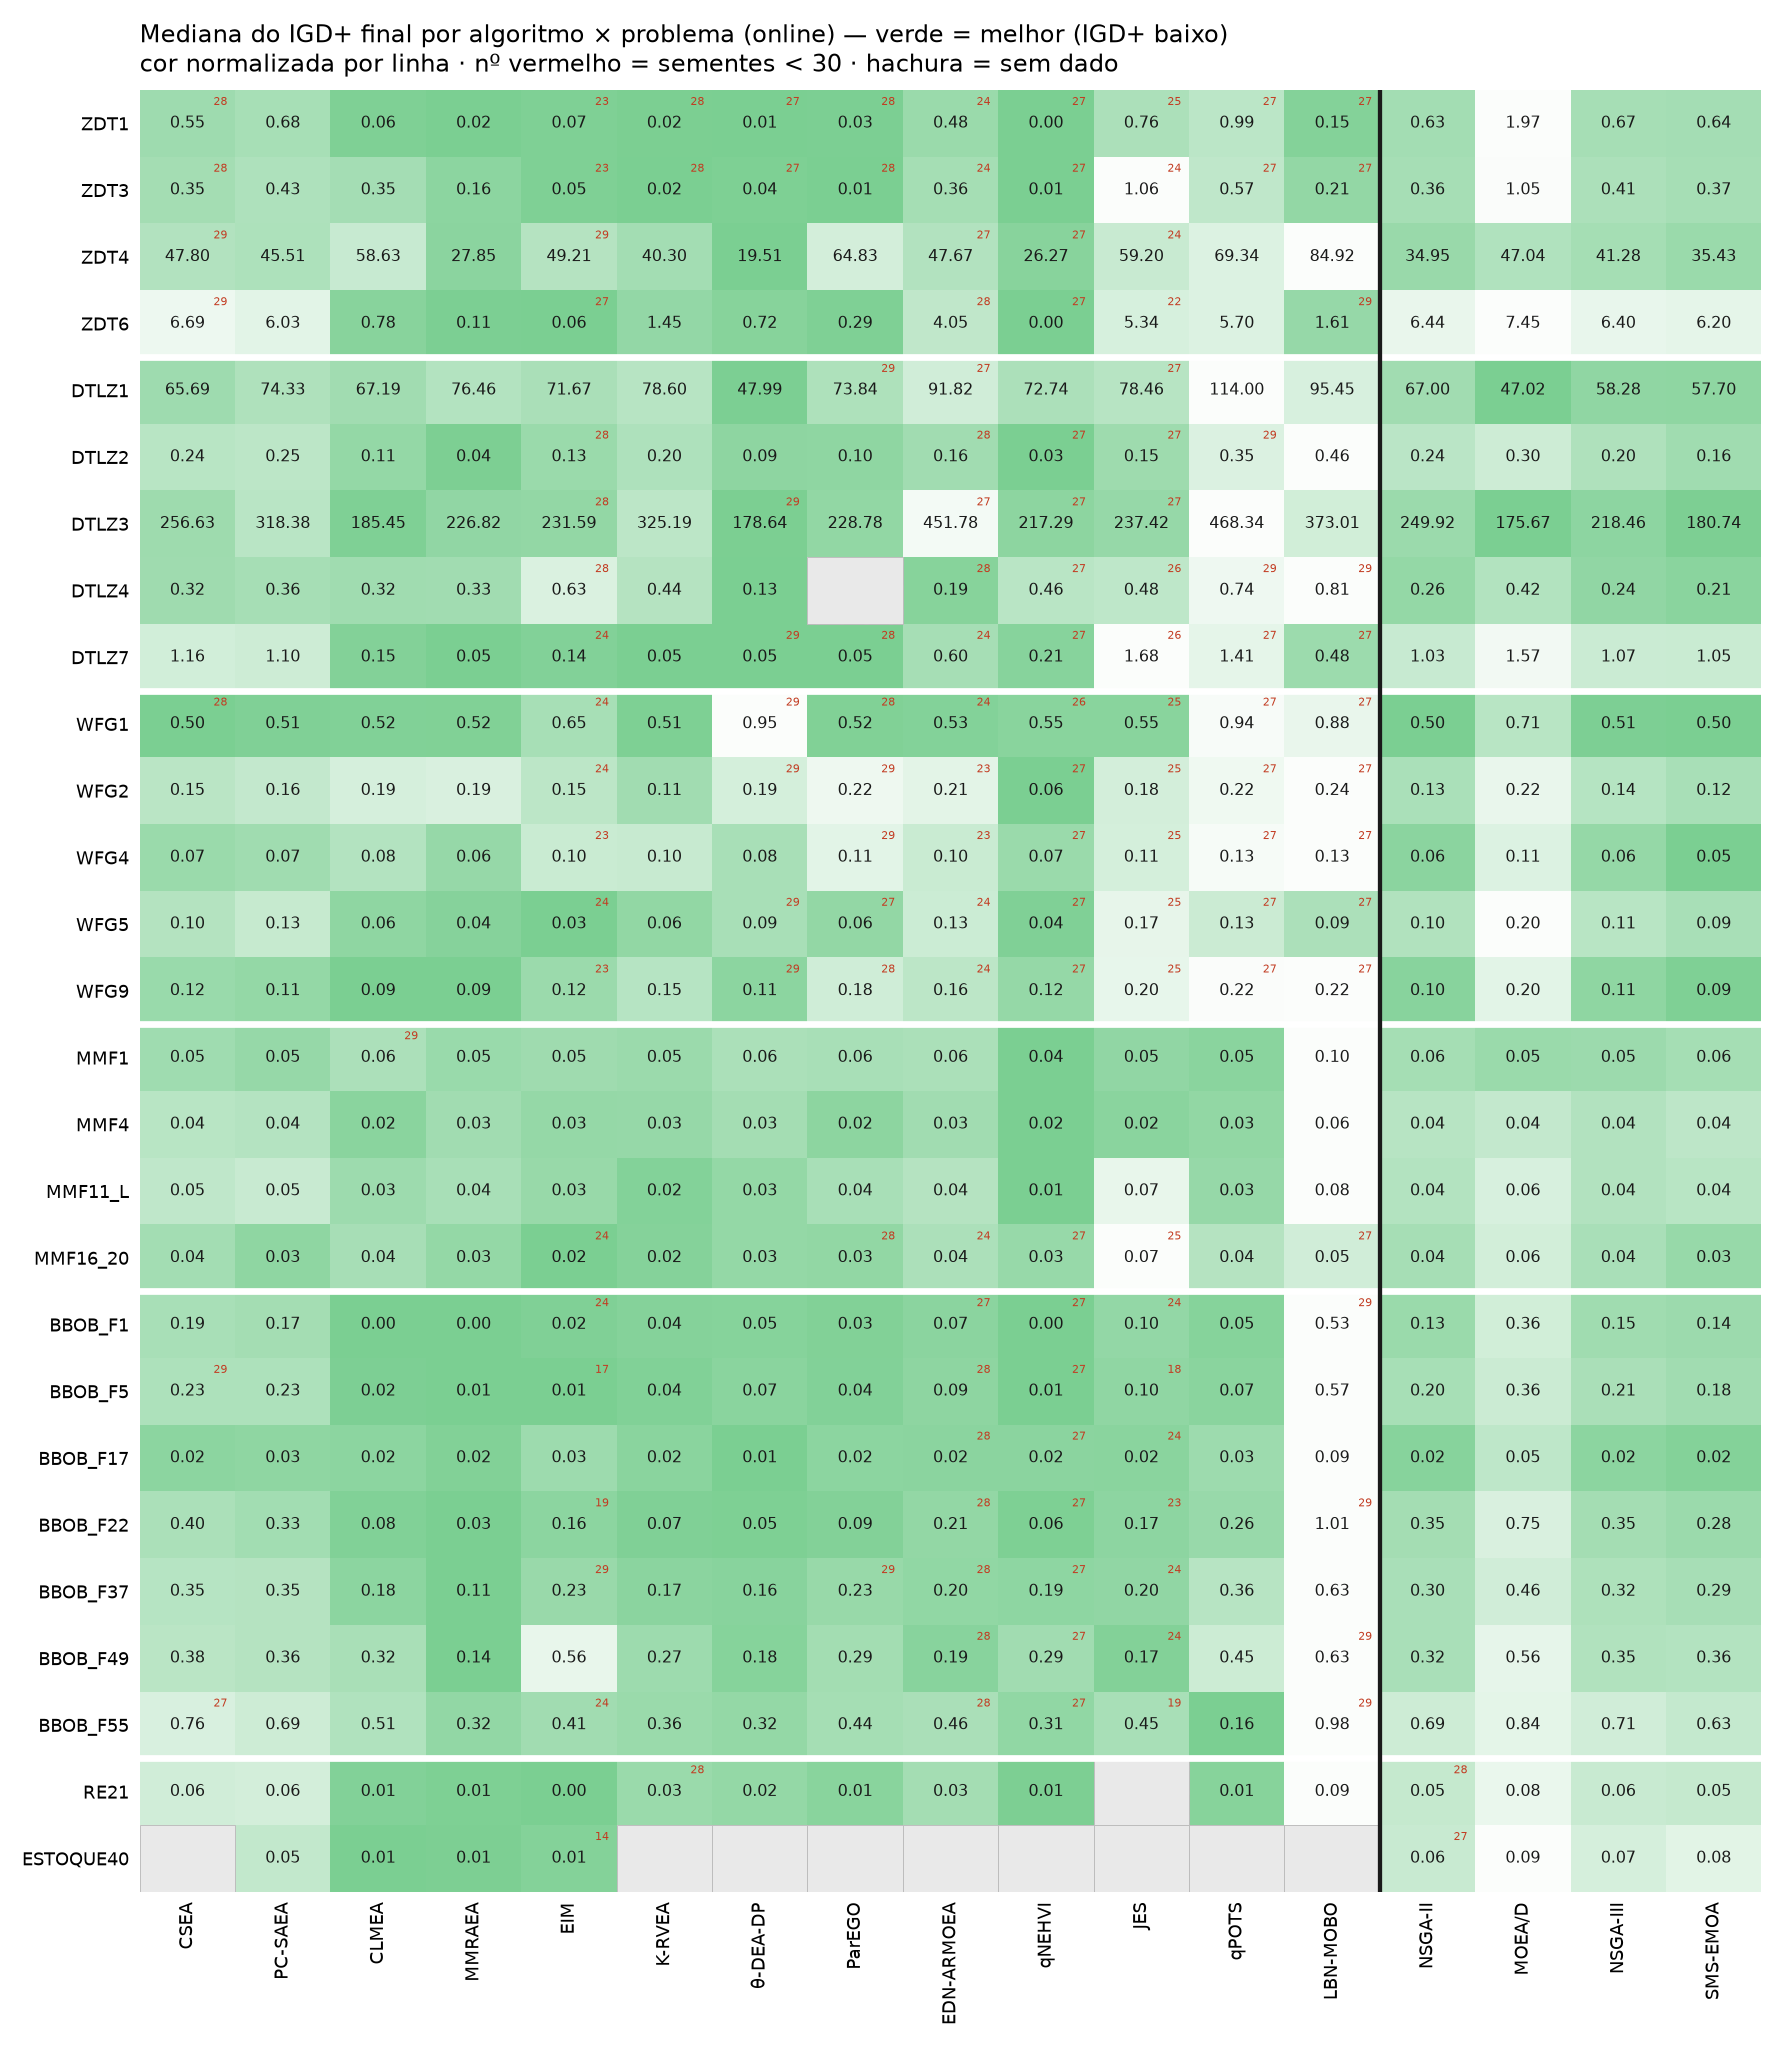

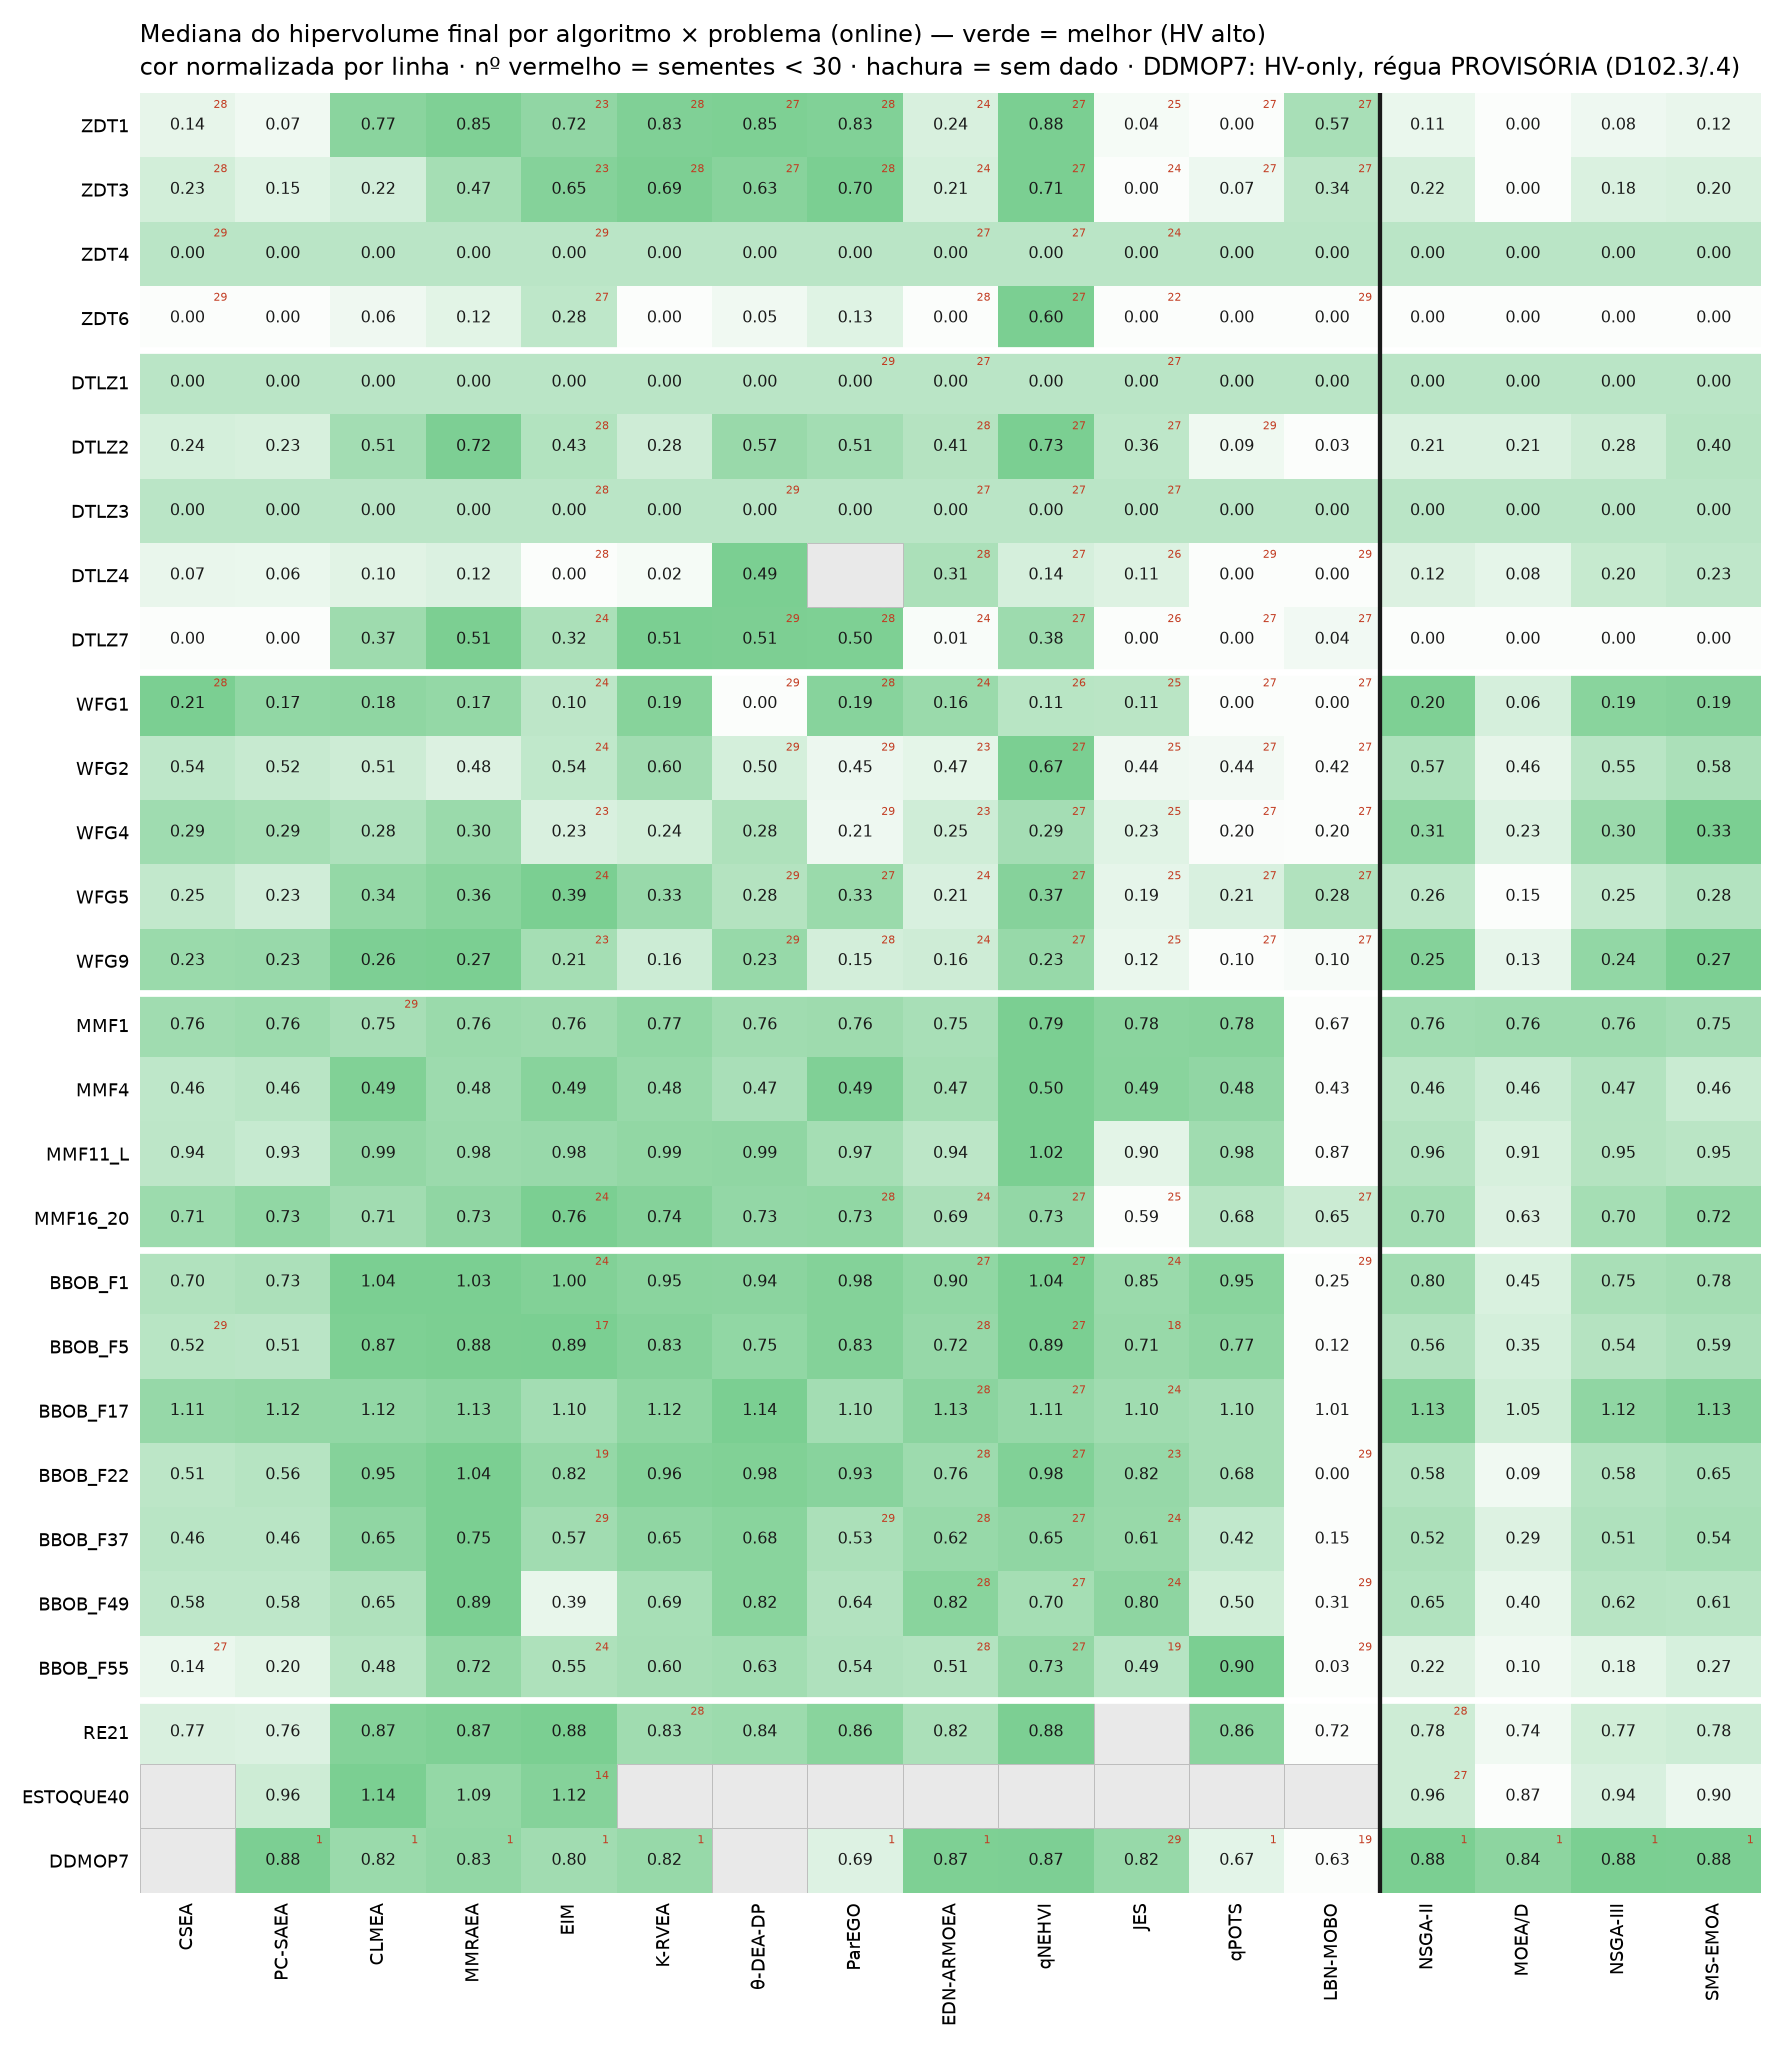

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

NOME = {"b1": "ParEGO", "b3": "K-RVEA", "b4": "CSEA", "c122": "θ-DEA-DP",
        "c141": "MMRAEA", "c149": "LBN-MOBO", "c154": "JES", "c217": "PC-SAEA",
        "c238": "EIM", "c262": "qNEHVI", "e7": "EDN-ARMOEA", "e74": "CLMEA",
        "e81": "qPOTS", "nsga2": "NSGA-II", "nsga3": "NSGA-III", "moead": "MOEA/D",
        "smsemoa": "SMS-EMOA", "b5m": "Prob-MOEA/D", "b5r": "Prob-RVEA",
        "e103": "IBEA-MS", "moead_media": "MOEA/D-média"}
ONLINE = ["b4", "c217", "e74", "c141", "c238", "b3", "c122", "b1", "e7",
          "c262", "c154", "e81", "c149", "nsga2", "moead", "nsga3", "smsemoa"]
PISO_DE = {"b4": "nsga2", "c217": "nsga2", "e74": "nsga2", "c141": "nsga2",
           "c238": "nsga2", "b3": "moead", "c122": "moead", "b1": "moead",
           "e7": "nsga3", "c262": "smsemoa"}
BANDA = ["c154", "e81", "c149"]
PISOS = ["nsga2", "moead", "nsga3", "smsemoa"]
OFFLINE = ["b5m", "b5r", "e103", "moead_media"]
PROBLEMAS = ["ZDT1", "ZDT3", "ZDT4", "ZDT6",
             "DTLZ1", "DTLZ2", "DTLZ3", "DTLZ4", "DTLZ7",
             "WFG1", "WFG2", "WFG4", "WFG5", "WFG9",
             "MMF1", "MMF4", "MMF11_L", "MMF16_20",
             "BBOB_F1", "BBOB_F5", "BBOB_F17", "BBOB_F22", "BBOB_F37",
             "BBOB_F49", "BBOB_F55", "RE21", "ESTOQUE40"]
SEPARA_APOS = {3, 8, 13, 17, 24}
VERDE = LinearSegmentedColormap.from_list("verde", ["#fbfdfb", "#7bcf92"])
DIVERG = LinearSegmentedColormap.from_list("div", ["#dfa07e", "#fbfbf9", "#7bcf92"])
on = ok[ok.exp == "main"]
off = ok[ok.exp == "off"]

def medianas(base, metrica, algs, problemas):
    med = pd.DataFrame(index=problemas, columns=algs, dtype=float)
    nse = pd.DataFrame(0, index=problemas, columns=algs, dtype=int)
    for a in algs:
        sub = base[base.alg == a]
        for p in problemas:
            v = sub[sub.problema == p][metrica].dropna()
            if len(v):
                med.loc[p, a] = float(v.median()); nse.loc[p, a] = len(v)
    return med, nse

def heat(ax, med, nse, cmap, invert, fmt=".2f", fs=5.4):
    vals = med.values.astype(float)
    C = np.full(vals.shape, np.nan)          # cor normalizada POR LINHA (SPEC L367)
    for i in range(vals.shape[0]):
        r, okm = vals[i], ~np.isnan(vals[i])
        if okm.sum() > 1 and np.nanmax(r) > np.nanmin(r):
            C[i, okm] = (r[okm] - np.nanmin(r)) / (np.nanmax(r) - np.nanmin(r))
        elif okm.any():
            C[i, okm] = 0.5
    if invert:
        C = 1.0 - C
    ax.imshow(np.ma.masked_invalid(C), cmap=cmap, aspect="auto", vmin=0, vmax=1)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isnan(vals[i, j]):
                ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color="#e9e9e9",
                                           hatch="///", ec="#bbbbbb", lw=.3))
                continue
            ax.text(j, i, format(vals[i, j], fmt), ha="center", va="center",
                    fontsize=fs, color="#1a1a1a")
            if 0 < nse.iloc[i, j] < 30:
                ax.text(j + .42, i - .40, str(nse.iloc[i, j]), ha="right",
                        va="top", fontsize=3.6, color="#c23b21")
    ax.set_xticks(range(vals.shape[1]))
    ax.set_xticklabels([NOME[a] for a in med.columns], rotation=90, fontsize=6)
    ax.set_yticks(range(vals.shape[0]))
    ax.set_yticklabels(med.index, fontsize=6)
    for s in SEPARA_APOS:
        if s < vals.shape[0]:
            ax.axhline(s + .5, color="white", lw=2.2)
    npiso = sum(1 for a in med.columns if a in PISOS)
    if npiso:
        ax.axvline(len(med.columns) - npiso - .5, color="#1a1a1a", lw=1.4)
    ax.tick_params(length=0)
    [sp.set_visible(False) for sp in ax.spines.values()]

EMBED_PNG = []
for metrica, invert, titulo, fname, probs in [
    ("igd_plus", True,
     "Mediana do IGD+ final por algoritmo × problema (online) — verde = melhor (IGD+ baixo)",
     "fig51_matriz_igdplus", PROBLEMAS),
    ("hv", False,
     "Mediana do hipervolume final por algoritmo × problema (online) — verde = melhor (HV alto)",
     "fig52_matriz_hv", PROBLEMAS + ["DDMOP7"]),
]:
    med, nse = medianas(on, metrica, ONLINE, probs)
    fig, ax = plt.subplots(figsize=(8.2, 9.4))
    heat(ax, med, nse, VERDE, invert)
    ax.set_title(titulo + "\ncor normalizada por linha · nº vermelho = sementes < 30 · hachura = sem dado"
                 + (" · DDMOP7: HV-only, régua PROVISÓRIA (D102.3/.4)" if "DDMOP7" in probs else ""),
                 fontsize=8, loc="left")
    fig.tight_layout()
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGDIR, f"{fname}.{ext}"), dpi=220, bbox_inches="tight")
    plt.close(fig)
    EMBED_PNG.append(os.path.join(FIGDIR, f"{fname}.png"))
    if metrica == "igd_plus":
        MED_IGDP = med
        rk = med[[a for a in ONLINE]].rank(axis=1)
        print("rank médio (IGD+, 25 sintéticos + RE21/ESTOQUE40; 1 = melhor):")
        print(rk.mean().sort_values().round(2).rename(index=NOME).to_string())
print("figuras 5.1 e 5.2 exportadas para", FIGDIR)


## §5 · O surrogate compra alguma coisa? (SA × piso casado — fig. 5.3)

**Objetivo.** A pergunta anterior a todas (torre, score 10). O desenho
responde por construção: cada algoritmo assistido tem um piso **casado ao seu
princípio de seleção** (SPEC §3.2/D25) — NSGA-II para os de dominância,
MOEA/D para os de decomposição, NSGA-III para o de indicador, SMS-EMOA para o
de hipervolume (espelho mecânico exato do qNEHVI); os três BO-especiais, sem
análogo populacional, são lidos contra o MELHOR dos 4 pisos (banda, D25).

**Como se calcula.** Dentro de cada (problema, semente) os dois partiram do
MESMO DoE — então a diferença `IGD+(piso) − IGD+(assistido)` é PAREADA
(D63/D87: a sorte da amostra inicial cancela). A célula mostra a MEDIANA dos
pares; verde = assistido melhor, laranja = piso melhor.

placar por algoritmo (problemas em que o assistido vence × perde do piso, IGD+):
  CSEA         vs NSGA-II        6 × 19
  PC-SAEA      vs NSGA-II        5 × 20
  CLMEA        vs NSGA-II       18 ×  7
  MMRAEA       vs NSGA-II       20 ×  5
  EIM          vs NSGA-II       16 ×  9
  K-RVEA       vs MOEA/D        21 ×  4
  θ-DEA-DP     vs MOEA/D        23 ×  2
  ParEGO       vs MOEA/D        18 ×  6
  EDN-ARMOEA   vs NSGA-III      13 × 12
  qNEHVI       vs SMS-EMOA      17 ×  8
  JES          vs melhor dos 4   8 × 17
  qPOTS        vs melhor dos 4   7 × 18
  LBN-MOBO     vs melhor dos 4   4 × 21


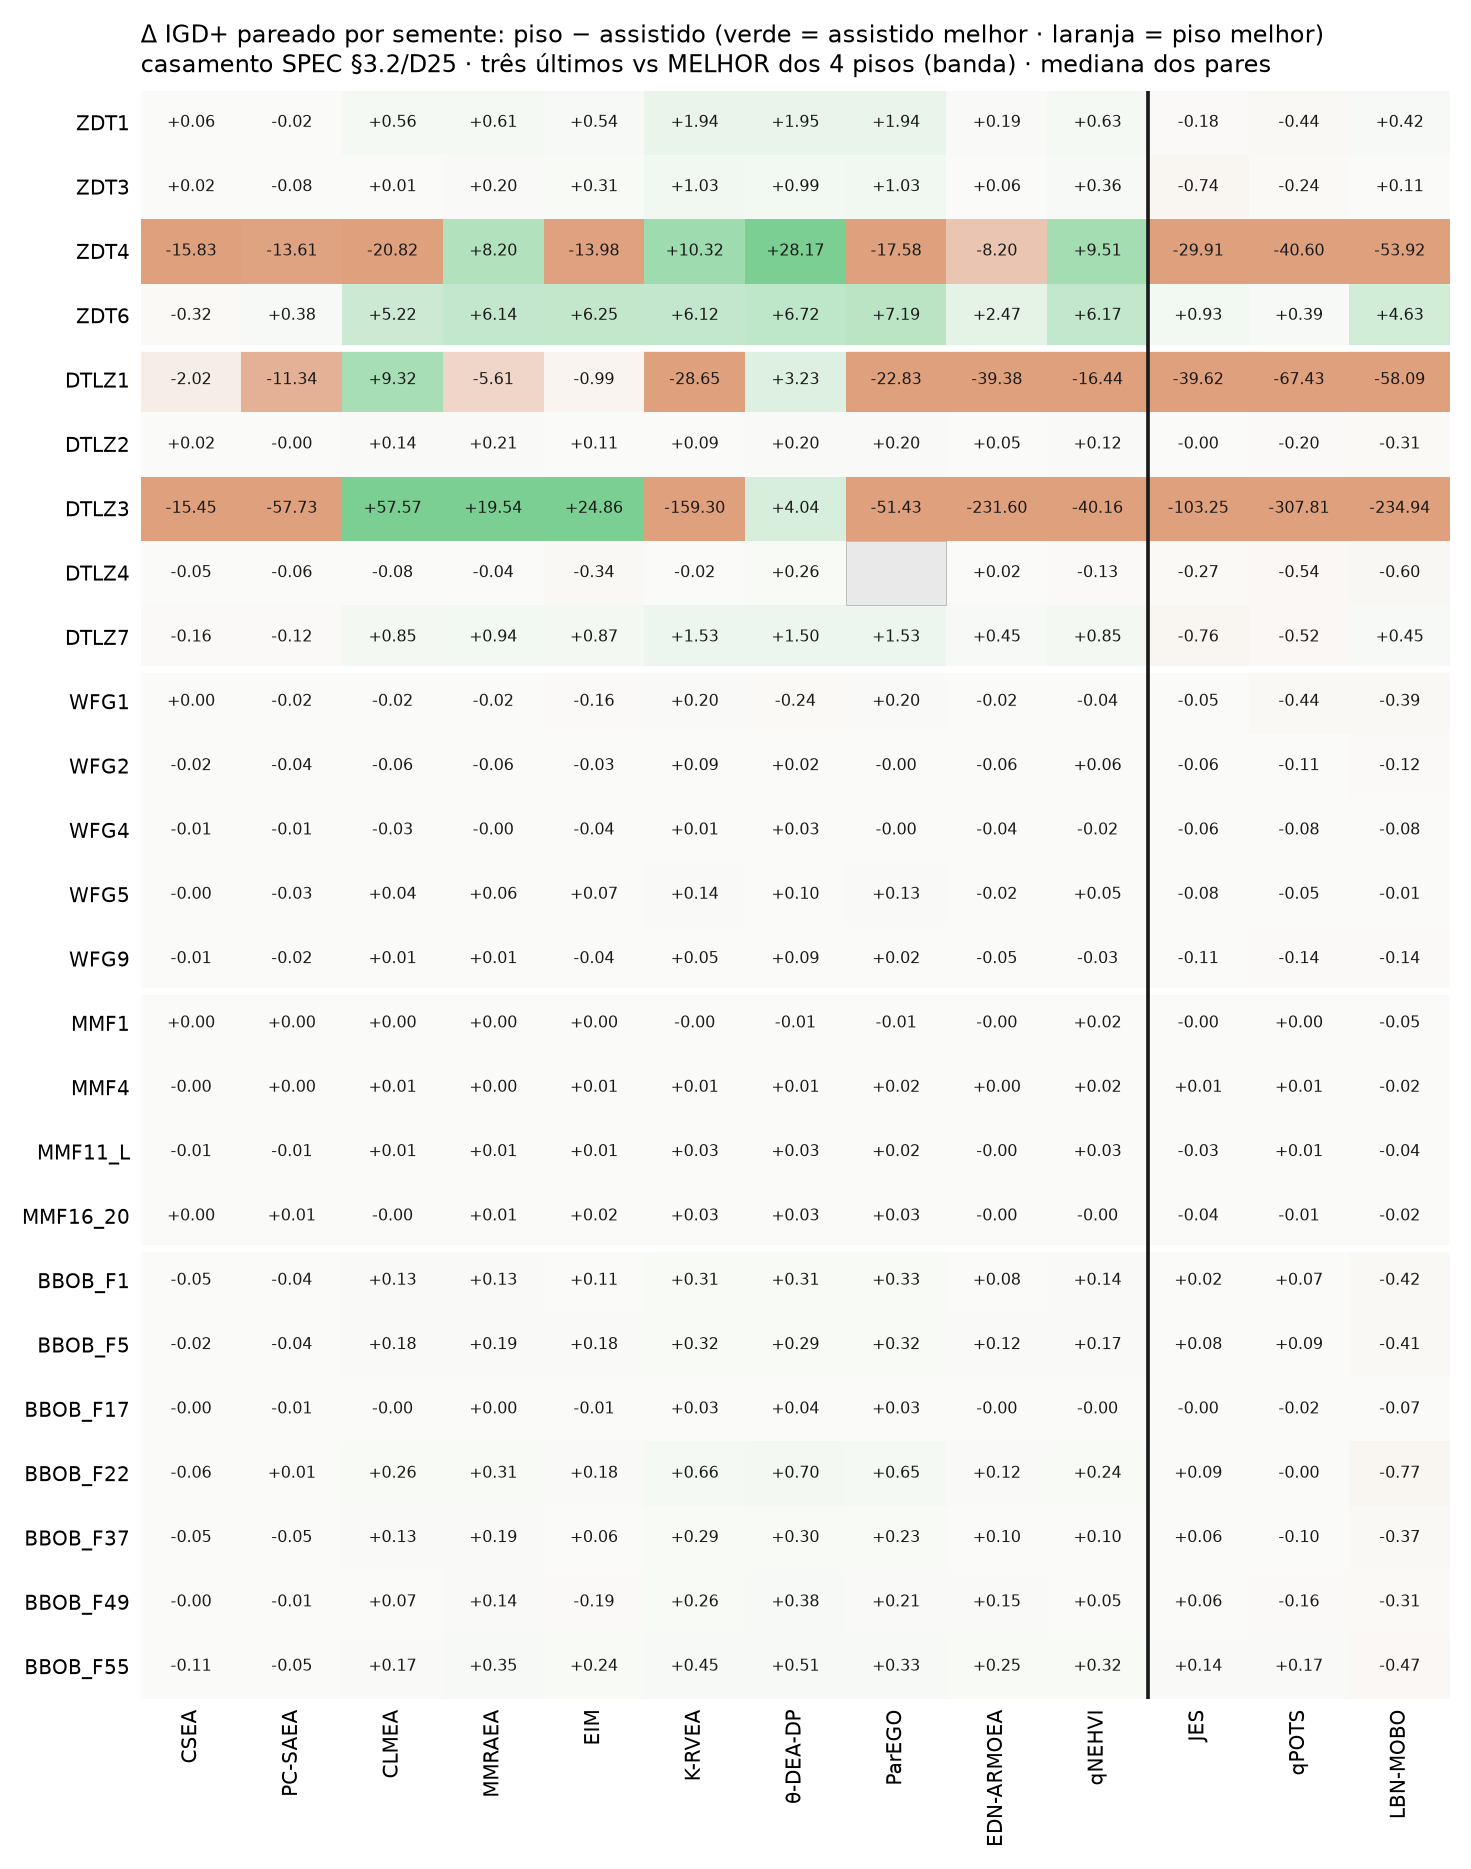

In [ ]:
SINTS = PROBLEMAS[:25]
SA = [a for a in ONLINE if a in PISO_DE] + BANDA
D = pd.DataFrame(index=SINTS, columns=SA, dtype=float)
PLACAR = {}
for a in SA:
    vit = der = 0
    sa_all = on[on.alg == a]
    for p in SINTS:
        sa = sa_all[sa_all.problema == p][["semente", "igd_plus"]].dropna()
        if a in PISO_DE:
            pi = on[(on.alg == PISO_DE[a]) & (on.problema == p)][["semente", "igd_plus"]].dropna()
            j = sa.merge(pi, on="semente", suffixes=("_sa", "_pi"))
        else:                                     # banda: contra o MELHOR dos 4 (D25)
            best = (on[(on.alg.isin(PISOS)) & (on.problema == p)]
                    .groupby("semente").igd_plus.min().rename("igd_plus_pi").reset_index())
            j = sa.rename(columns={"igd_plus": "igd_plus_sa"}).merge(best, on="semente")
        if len(j) >= 5:
            D.loc[p, a] = float((j.igd_plus_pi - j.igd_plus_sa).median())
            vit += D.loc[p, a] > 0; der += D.loc[p, a] < 0
    PLACAR[a] = (int(vit), int(der))

lim = float(np.nanpercentile(np.abs(D.values.astype(float)), 92))
fig, ax = plt.subplots(figsize=(6.8, 8.6))
V = D.values.astype(float)
ax.imshow(np.ma.masked_invalid(np.clip(V, -lim, lim)), cmap=DIVERG, vmin=-lim,
          vmax=lim, aspect="auto")
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        if np.isnan(V[i, j]):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color="#e9e9e9",
                                       hatch="///", ec="#bbbbbb", lw=.3))
        else:
            ax.text(j, i, f"{V[i, j]:+.2f}", ha="center", va="center", fontsize=5.2,
                    color="#1a1a1a")
ax.set_xticks(range(len(SA)))
ax.set_xticklabels([NOME[a] for a in SA], rotation=90, fontsize=6.5)
ax.set_yticks(range(len(SINTS)))
ax.set_yticklabels(SINTS, fontsize=6.5)
for s in sorted(SEPARA_APOS - {24}):
    ax.axhline(s + .5, color="white", lw=2.2)
ax.axvline(9.5, color="#1a1a1a", lw=1.2)
ax.set_title("Δ IGD+ pareado por semente: piso − assistido (verde = assistido melhor · laranja = piso melhor)\n"
             "casamento SPEC §3.2/D25 · três últimos vs MELHOR dos 4 pisos (banda) · mediana dos pares",
             fontsize=8, loc="left")
ax.tick_params(length=0)
[sp.set_visible(False) for sp in ax.spines.values()]
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig53_sa_vs_pisos.{ext}"), dpi=220,
                bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig53_sa_vs_pisos.png")]
print("placar por algoritmo (problemas em que o assistido vence × perde do piso, IGD+):")
for a in SA:
    ref = NOME[PISO_DE[a]] if a in PISO_DE else "melhor dos 4"
    print(f"  {NOME[a]:12s} vs {ref:12s}  {PLACAR[a][0]:2d} × {PLACAR[a][1]:2d}")


## §6 · O regime offline e a ablação exata do σ (fig. 5.4)

**Objetivo.** O contraste mais cirúrgico da bateria: **Prob-MOEA/D × MOEA/D-média**
diferem SOMENTE no uso do desvio-padrão do modelo (mesmo dataset por semente,
mesmo surrogate GP, mesma maquinaria de busca — D90/§10). Qualquer diferença
pareada mede, isoladamente, o valor de usar a incerteza. IBEA-MS aparece como
`final_ausente` até a escalação F30 da ⑦ ser resolvida pelo autor.

ablação exata do σ (Prob-MOEA/D × MOEA/D-média, Δ IGD+ pareado; >0 = usar σ ajudou):
  σ ajuda em 15 de 25 problemas; piores/melhores casos:
    ZDT6       -1.2489
    ZDT1       -0.8289
    DTLZ7      -0.5604
    ZDT4       +43.1074
    DTLZ3      +48.9558
    DTLZ1      +55.9563
resumo salvo em data/analysis_cache/resumo_analises_2026-08-17.json


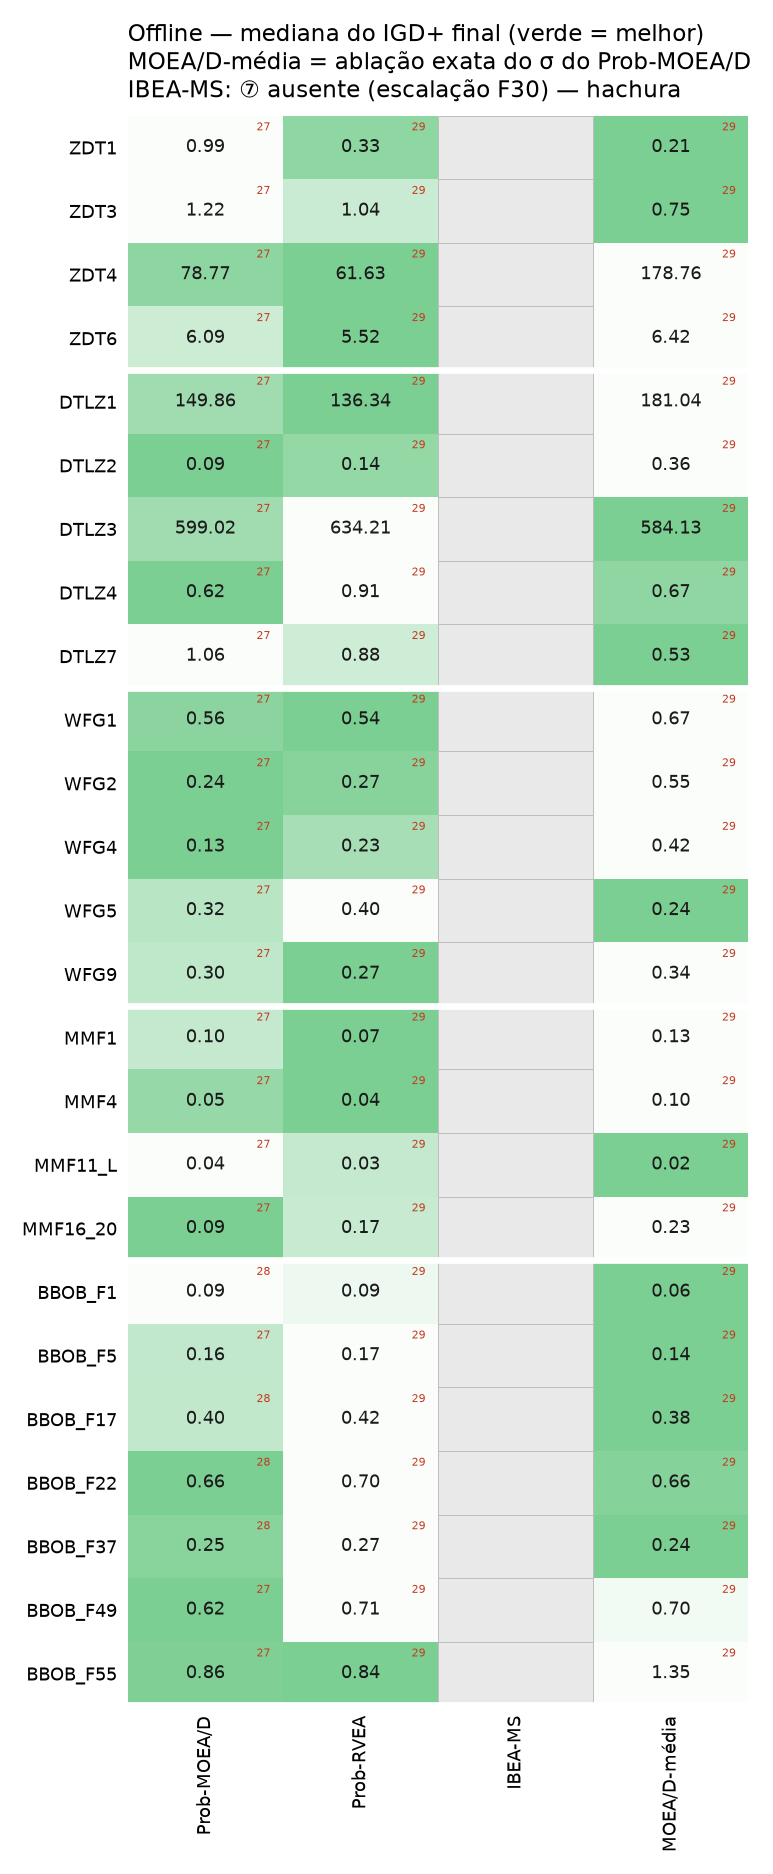

In [ ]:
SINTS = PROBLEMAS[:25]
medo, nseo = medianas(off, "igd_plus", OFFLINE, SINTS)
fig, ax = plt.subplots(figsize=(3.6, 8.6))
heat(ax, medo, nseo, VERDE, True, fs=5.8)
ax.set_title("Offline — mediana do IGD+ final (verde = melhor)\n"
             "MOEA/D-média = ablação exata do σ do Prob-MOEA/D\n"
             "IBEA-MS: ⑦ ausente (escalação F30) — hachura",
             fontsize=7.5, loc="left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig54_offline.{ext}"), dpi=220,
                bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig54_offline.png")]

ABL = {}
for p in SINTS:
    s1 = off[(off.alg == "b5m") & (off.problema == p)][["semente", "igd_plus"]].dropna()
    s0 = off[(off.alg == "moead_media") & (off.problema == p)][["semente", "igd_plus"]].dropna()
    j = s1.merge(s0, on="semente", suffixes=("_sigma", "_media"))
    if len(j) >= 5:
        ABL[p] = float((j.igd_plus_media - j.igd_plus_sigma).median())
pos = sum(1 for v in ABL.values() if v > 0)
print(f"ablação exata do σ (Prob-MOEA/D × MOEA/D-média, Δ IGD+ pareado; >0 = usar σ ajudou):")
print(f"  σ ajuda em {pos} de {len(ABL)} problemas; piores/melhores casos:")
for p, v in sorted(ABL.items(), key=lambda kv: kv[1]):
    if p in [k for k, _ in sorted(ABL.items(), key=lambda kv: kv[1])[:3]] or \
       p in [k for k, _ in sorted(ABL.items(), key=lambda kv: kv[1])[-3:]]:
        print(f"    {p:10s} {v:+.4f}")

resumo = {"snapshot": "2026-08-17",
          "placar_sa_vs_piso": {NOME[a]: PLACAR[a] for a in PLACAR},
          "ablacao_b5m_vs_media": ABL,
          "rank_medio_igdp_online": json.loads(
              MED_IGDP.rank(axis=1).mean().sort_values().round(3).rename(index=NOME).to_json())}
with open(os.path.join(CACHE, "resumo_analises_2026-08-17.json"), "w") as f:
    json.dump(resumo, f, ensure_ascii=False, indent=1)
print("resumo salvo em data/analysis_cache/resumo_analises_2026-08-17.json")


## §7 · Conferências desta execução

1. o gate D92 (§2) passou na âncora analítica;
2. contra-cálculo INDEPENDENTE do HV (Monte Carlo, 200k pontos) numa amostra
   de células — caminho diferente do box-decomposition do pymoo;
3. `avisos_regua` — furos TOLERADOS da régua (arredondamento declarado da S.5,
   três ordens de grandeza abaixo do corte do guard, T15.13b).

In [ ]:
rng = np.random.default_rng(4242)
amostra = ok[(ok.exp == "main") & (ok.problema.isin(["ZDT1", "DTLZ2", "WFG4", "BBOB_F5"]))].sample(6, random_state=42)
piores = []
for _, r in amostra.iterrows():
    f = glob.glob(os.path.join(CORPUS, r.alg, r.problema, str(r.semente), "*__real.parquet"))[0]
    t = pq.read_table(f)
    fc = sorted([c for c in t.column_names if re.fullmatch(r"f\d+", c)], key=lambda c: int(c[1:]))
    F = np.column_stack([np.asarray(t.column(c), float) for c in fc])
    ideal, nadir = metrics.reference_bounds(r.problema)
    A = metrics.normalize(metrics.nondominated_front(F), ideal, nadir)
    M = A.shape[1]
    U = rng.random((200_000, M)) * metrics.HV_REF_COORD
    dom = np.zeros(len(U), bool)
    for a in A:
        dom |= (U >= a).all(axis=1)
    hv_mc = dom.mean() * metrics.HV_REF_COORD ** M
    piores.append(abs(hv_mc - r.hv))
    print(f"{r.alg:12s} {r.problema:9s} s{int(r.semente):2d}  HV oficial {r.hv:.4f} · MC {hv_mc:.4f} · |Δ| {abs(hv_mc-r.hv):.4f}")
assert max(piores) < 0.01, "contra-cálculo MC divergiu do HV oficial"
print("contra-cálculo MC: OK (|Δ| máx = %.4f, dentro do erro de amostragem)" % max(piores))
print("avisos_regua (furos tolerados, T15.13b):", {k: (int(v[0]), round(float(v[1]), 6)) for k, v in metrics.avisos_regua.items()} or "— (ledger do processo principal; os furos conhecidos são ZDT6/MMF4/MMF1, arredondamento declarado)")

c262         WFG4      s15  HV oficial 0.2819 · MC 0.2806 · |Δ| 0.0012
nsga2        WFG4      s22  HV oficial 0.3222 · MC 0.3226 · |Δ| 0.0004
smsemoa      DTLZ2     s25  HV oficial 0.4188 · MC 0.4209 · |Δ| 0.0021
c238         DTLZ2     s 7  HV oficial 0.4311 · MC 0.4324 · |Δ| 0.0014
b4           ZDT1      s 7  HV oficial 0.1365 · MC 0.1356 · |Δ| 0.0009
c141         BBOB_F5   s 2  HV oficial 0.8830 · MC 0.8815 · |Δ| 0.0016
contra-cálculo MC: OK (|Δ| máx = 0.0021, dentro do erro de amostragem)
avisos_regua (furos tolerados, T15.13b): — (ledger do processo principal; os furos conhecidos são ZDT6/MMF4/MMF1, arredondamento declarado)


# PARTE II · As análises do processo seletivo (17/08, 2ª leva)

**De onde vêm.** O autor extraiu, com outra instância, o ranking das análises que os
artigos do corpus mais fazem (planilhas `analises_experimentais_*`), e 7 leitores
extraíram dos exemplares (K-RVEA, NSGAIII-EHVI, RVMM, EDN-ARMOEA, CSEA, IBEA-MS,
EMMOEA, qNEHVI, JES) as CONVENÇÕES práticas de cada análise. As convenções adotadas:
célula = mediana (o corpus usa média(dp); mediana é mais robusta e é o endpoint D70) ·
Wilcoxon rank-sum α=0,05 sem correção (a convenção dominante) · execução da MEDIANA
do IGD+ para fronteiras · curvas mediana+IQR · tempo como TENDÊNCIA com ressalva de
plataforma · calibração σ×|erro| que NENHUM exemplar faz (nossa lacuna→contribuição).

**Os 7 artefatos de saída por célula** (`CONTRATO_DE_DADOS.md`):

| # | Arquivo | O que guarda |
|---|---------|--------------|
| ① | `__real.parquet` | toda avaliação REAL (X, f verdadeiro, fe_index, fase) |
| ② | `__pop.parquet` | pertencimento população × geração (solution_id) |
| ③ | `__surrogate.parquet` | TODA predição do modelo (μ/σ por candidato×geração) + blocos da SONDA |
| ④ | `__timing.parquet` | tempo por geração: fit do surrogate · busca · sonda |
| ⑤ | `.manifest.json` | certidão do run (status, hashes, params, timing agregado) |
| ⑥ | `.jsonl` | o FILME das decisões (1 evento/linha, com timestamps) |
| ⑦ | `__final.parquet` | SÓ offline: o ND final REAVALIADO na função verdadeira |

**Matriz análise × artefato** (como cada saída alimenta cada análise):

| Análise | ① | ② | ③ | ④ | ⑤ | ⑥ | ⑦ |
|---|---|---|---|---|---|---|---|
| §5.1 Completude | conta células | — | — | — | status ok/teto | categoriza abortos | presença (offline) |
| §5.2 Matrizes IGD+/HV | ND final → métricas | — | — | — | — | — | endpoint offline |
| §5.3 SA×pisos pareado | métricas pareadas por semente | — | — | — | — | — | — |
| §5.4 Ablação do σ | — | — | — | — | — | — | b5m × moead_media |
| A1 Wilcoxon vs melhor | métricas por semente | — | — | — | — | — | — |
| A2 Friedman + CD | ranks das medianas | — | — | — | — | — | — |
| A3 Característica × alg. | ranks estratificados | — | — | — | — | — | — |
| A4 Trajetórias | ND acumulado por corte de fe_index | — | — | — | — | — | — |
| A5 Erro de fantasia | f real (join por solution_id) | — | μ dos pontos escolhidos | — | — | — | — |
| A6 Sonda (calibração) | — | — | blocos regime=sonda (μ,σ) × f verdadeiro do artefato | cadência | — | eventos rec=sonda | — |
| A7 Pares seminal→SOTA | métricas pareadas | — | — | — | — | — | — |
| A8 Fronteiras | ND da run mediana | — | — | — | — | — | — |
| A9 Tempo × qualidade | qualidade (rank) | — | — | fit/busca/sonda por geração | wall-clock total | timestamps (conferência) | — |
| A10 Utilidade do infill | ordem fe_index + fase | — | — | — | — | — | — |

**Nota sobre a ②:** o pertencimento população×geração alimenta o "filme" completo do
erro de fantasia por geração (fronteira ACREDITADA vs real) — nesta leva o erro de
fantasia usa a versão pareada por ponto escolhido (③×①); a reconstrução geracional
com a ② fica na fila (exige as ③ do bucket para os volumosos).

## A1+A2 · A comparação global: Wilcoxon vs o melhor + diagrama de diferença crítica

**Objetivo.** A1 responde 'quem empata com o melhor onde' célula a célula (a tabela canônica do campo, na convenção e86/e104: rank-sum α=0,05, símbolos vs referência, linha agregada). A2 colapsa tudo num veredito global: rank médio + Friedman (omnibus) + Nemenyi (pós-teste): algoritmos ligados pela barra NÃO se distinguem estatisticamente (Demšar). Nota d19: leitura por grupos, sem decretar vencedor EA×BO.

A1 · vs o MELHOR de cada problema (IGD+, 25 sintéticos; rank-sum α=0,05):
            melhor  indistinguivel  pior  melhor_ou_ind
alg                                                    
qNEHVI           9               3    13             12
MMRAEA           4               3    18              7
θ-DEA-DP         3               4    18              7
SMS-EMOA         2               3    20              5
CLMEA            0               3    22              3
EIM              2               1    22              3
MOEA/D           2               0    23              2
NSGA-II          0               2    23              2
EDN-ARMOEA       0               2    23              2
ParEGO           1               1    22              2
K-RVEA           1               1    23              2
JES              0               1    24              1
qPOTS            1               0    24              1
NSGA-III         0               1    24              1
CSEA             0            

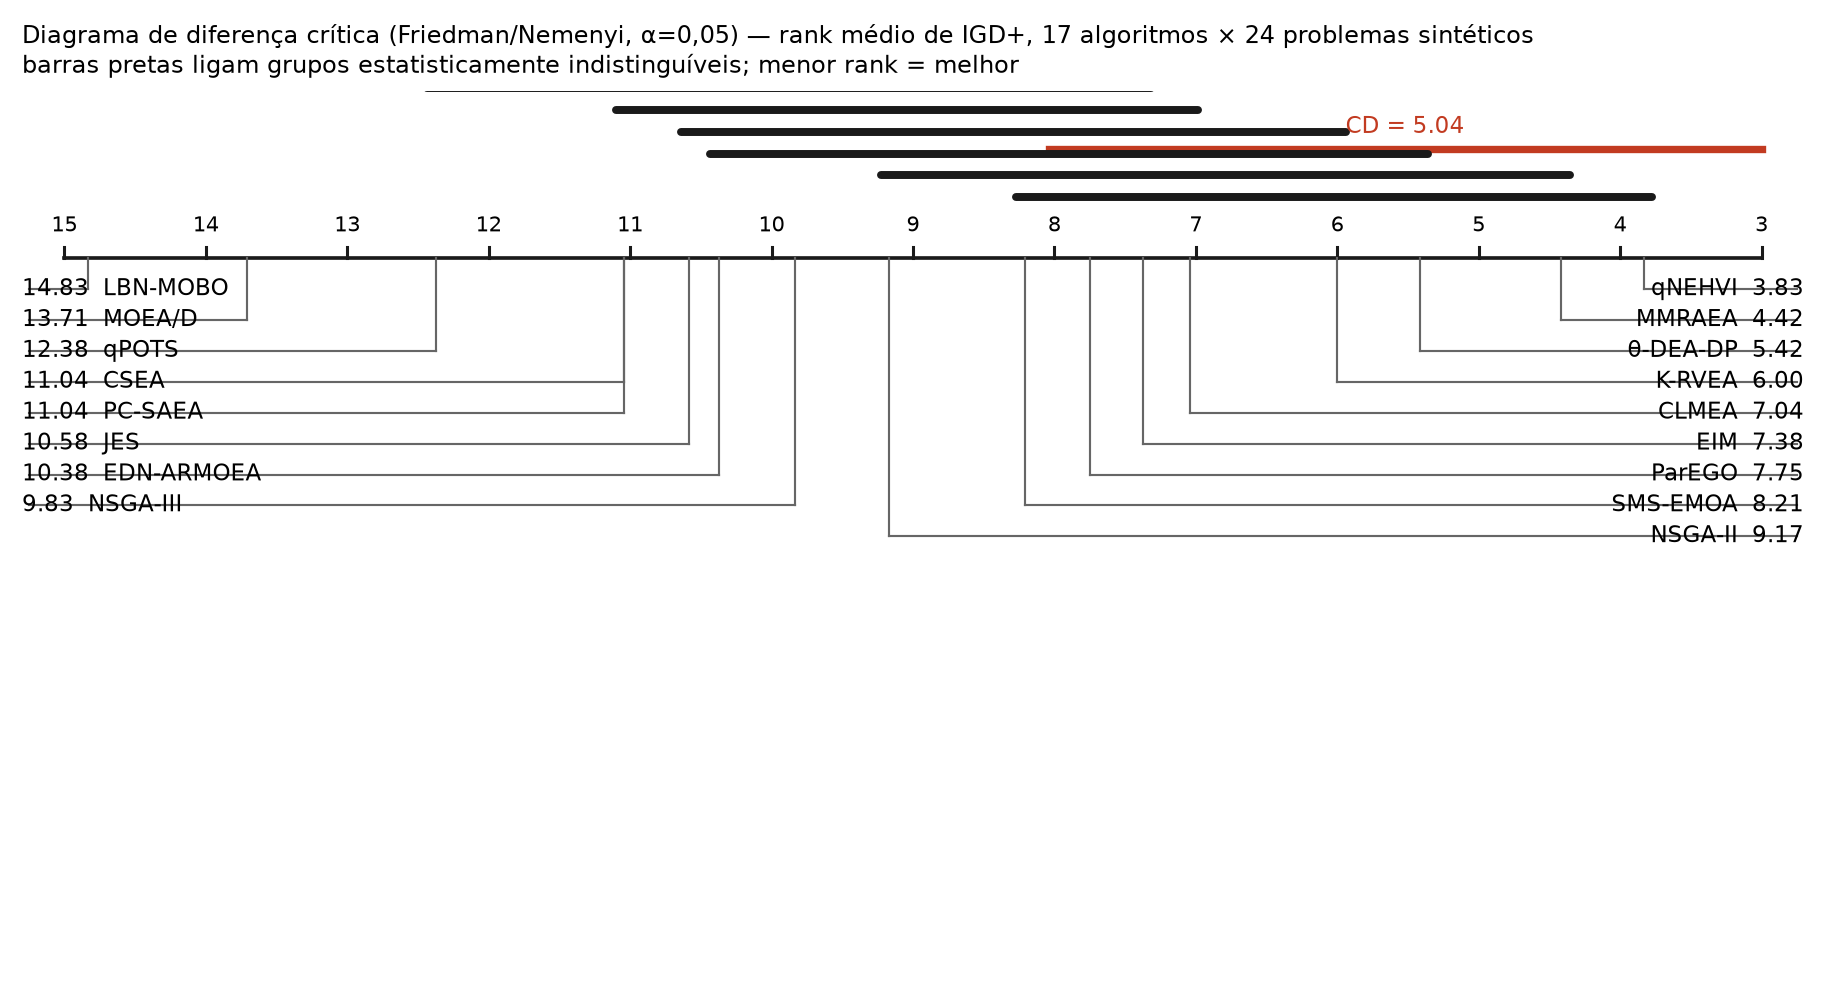

In [ ]:
import scipy.stats as st

SINTS = PROBLEMAS[:25]
# ---- A1 · Wilcoxon vs o melhor do problema (convenção do corpus: rank-sum, α=0,05, sem correção)
resumo_wx = []
for a in ONLINE:
    v = e = d = 0
    for p in SINTS:
        sub = on[on.problema == p]
        med = sub.groupby("alg").igd_plus.median()
        if a not in med.index or med.isna().all():
            continue
        best = med.idxmin()
        if best == a:
            v += 1
            continue
        xa = sub[sub.alg == a].igd_plus.dropna()
        xb = sub[sub.alg == best].igd_plus.dropna()
        if len(xa) >= 5 and len(xb) >= 5:
            pval = st.ranksums(xa, xb).pvalue
            if pval >= 0.05:
                e += 1
            else:
                d += 1
    resumo_wx.append(dict(alg=NOME[a], melhor=v, indistinguivel=e, pior=d))
WX = pd.DataFrame(resumo_wx).set_index("alg")
WX["melhor_ou_ind"] = WX.melhor + WX.indistinguivel
WX = WX.sort_values("melhor_ou_ind", ascending=False)
print("A1 · vs o MELHOR de cada problema (IGD+, 25 sintéticos; rank-sum α=0,05):")
print(WX.to_string())

# ---- A2 · Friedman + Nemenyi CD (Demšar) sobre os ranks de IGD+ (online, 25 sintéticos)
med = on[on.problema.isin(SINTS)].groupby(["problema", "alg"]).igd_plus.median().unstack()
med = med[[a for a in ONLINE if a in med.columns]].dropna()
ranks = med.rank(axis=1)
k, N = ranks.shape[1], ranks.shape[0]
fr = st.friedmanchisquare(*[med[c] for c in med.columns])
Q_05 = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031,
        9: 3.102, 10: 3.164, 11: 3.219, 12: 3.268, 13: 3.313, 14: 3.354,
        15: 3.391, 16: 3.426, 17: 3.458, 18: 3.489, 19: 3.517, 20: 3.544}
CD = Q_05[k] * np.sqrt(k * (k + 1) / (6.0 * N))
rm = ranks.mean().sort_values()
print(f"\nA2 · Friedman: χ²={fr.statistic:.1f}, p={fr.pvalue:.2e} · k={k}, N={N} · CD(Nemenyi, α=0,05)={CD:.2f}")

fig, ax = plt.subplots(figsize=(8.4, 4.6))
lo, hi = np.floor(rm.min()), np.ceil(rm.max())
ax.set_xlim(hi + .3, lo - .3); ax.set_ylim(-(k / 2 + 2.5), 2.6)
ax.axis("off")
ax.plot([lo, hi], [0, 0], color="#1a1a1a", lw=1.2)
for t in np.arange(lo, hi + .1, 1):
    ax.plot([t, t], [0, .18], color="#1a1a1a", lw=1)
    ax.text(t, .42, f"{int(t)}", ha="center", fontsize=7)
ax.plot([lo, lo + CD], [1.7, 1.7], color="#c23b21", lw=2.4)
ax.text(lo + CD / 2, 1.95, f"CD = {CD:.2f}", ha="center", fontsize=7.5, color="#c23b21")
esq = rm.index[: (k + 1) // 2]; dir_ = rm.index[(k + 1) // 2:]
for i, a in enumerate(esq):
    y = -(i + 1)
    ax.plot([rm[a], rm[a]], [0, y * .48], color="#666666", lw=.7)
    ax.plot([rm[a], lo - .25], [y * .48, y * .48], color="#666666", lw=.7)
    ax.text(lo - .3, y * .48, f"{NOME[a]}  {rm[a]:.2f}", ha="right", va="center", fontsize=7.4)
for i, a in enumerate(dir_):
    y = -(len(dir_) - i)
    ax.plot([rm[a], rm[a]], [0, y * .48], color="#666666", lw=.7)
    ax.plot([rm[a], hi + .25], [y * .48, y * .48], color="#666666", lw=.7)
    ax.text(hi + .3, y * .48, f"{rm[a]:.2f}  {NOME[a]}", ha="left", va="center", fontsize=7.4)
# barras de grupos indistinguíveis (varredura clássica)
grupos, usados = [], set()
vals = rm.values; nomes = list(rm.index)
for i in range(k):
    j = i
    while j + 1 < k and vals[j + 1] - vals[i] <= CD:
        j += 1
    if j > i and not any(i >= a and j <= b for a, b in grupos):
        grupos.append((i, j))
yg = .95
for a, b in grupos:
    ax.plot([vals[a] - .06, vals[b] + .06], [yg, yg], color="#1a1a1a", lw=2.6,
            solid_capstyle="round")
    yg += .34
ax.set_title("Diagrama de diferença crítica (Friedman/Nemenyi, α=0,05) — rank médio de IGD+, "
             f"{k} algoritmos × {N} problemas sintéticos\nbarras pretas ligam grupos "
             "estatisticamente indistinguíveis; menor rank = melhor", fontsize=8, loc="left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig55_cd_diagram.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig55_cd_diagram.png")]
print(rm.rename(index=NOME).round(2).to_string())


## A3 · Característica do problema × algoritmo (a leitura da tese)

**Objetivo.** O elo que a matriz da §4.3 promete: agrupa os problemas pela característica ESTRESSADA (matriz de características congelada) e lê o rank médio de cada algoritmo dentro de cada grupo — a versão-piloto da análise por escadinha (a versão completa vem com o corpus congelado).

A3 · melhor algoritmo por característica (rank médio de IGD+):
multimodalidade        qNEHVI
enganosidade           MMRAEA
frente desconexa       K-RVEA
densidade enviesada    MMRAEA
não separável          MMRAEA
alta dimensão          K-RVEA
frente côncava         qNEHVI


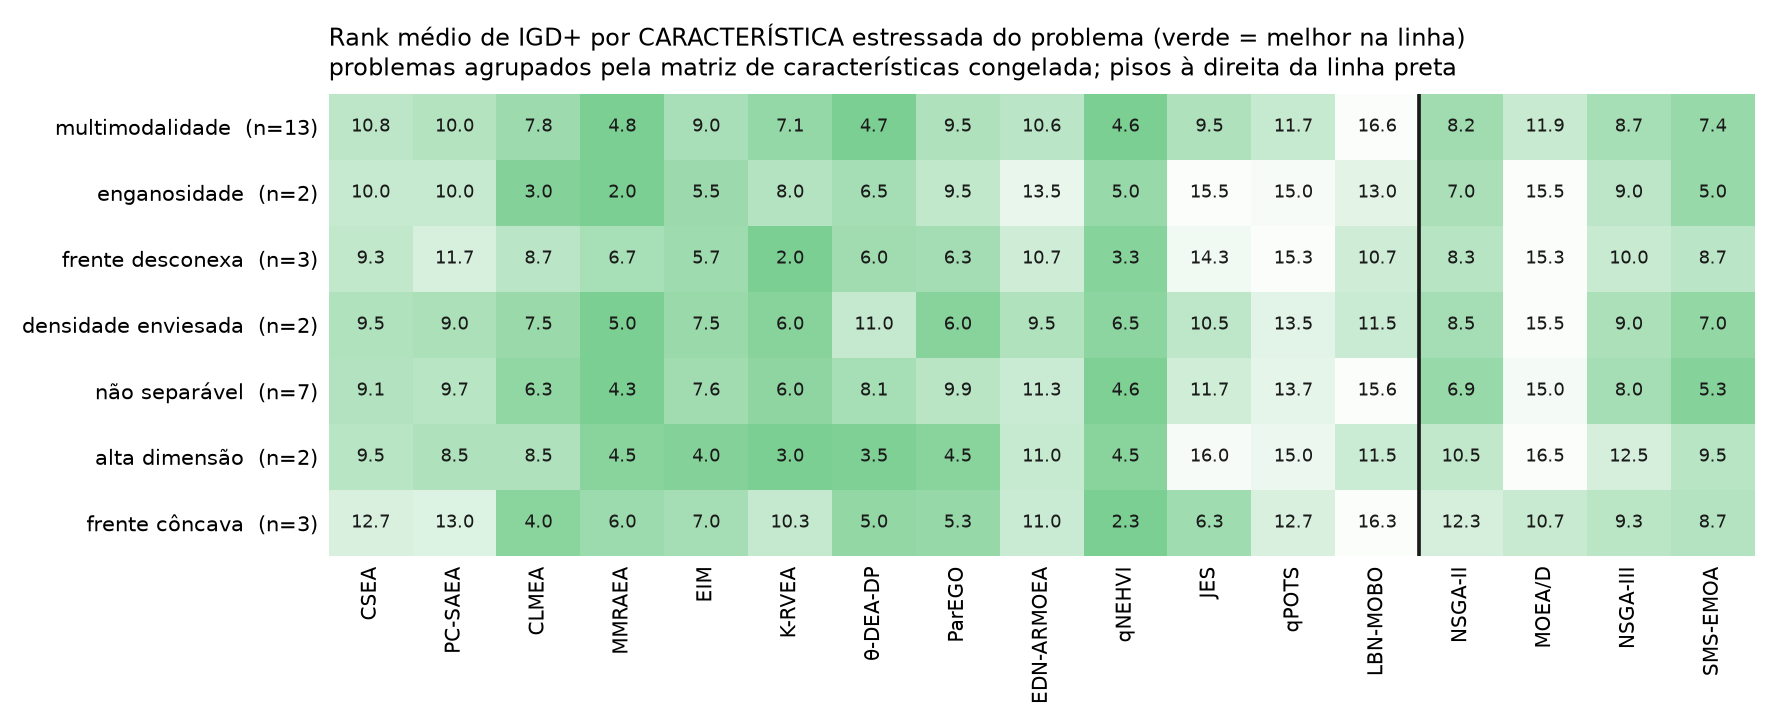

In [ ]:
CAR = pd.read_csv(os.path.join(UA, "claude_code_context", "artifacts", "characteristics.csv"))
CARCOLS = ["multimodal", "deceptive", "disconnected", "biased_density",
           "nonseparable", "high_dim", "concave_front"]
ROTULO = {"multimodal": "multimodalidade", "deceptive": "enganosidade",
          "disconnected": "frente desconexa", "biased_density": "densidade enviesada",
          "nonseparable": "não separável", "high_dim": "alta dimensão",
          "concave_front": "frente côncava"}
med = on[on.problema.isin(PROBLEMAS[:25])].groupby(["problema", "alg"]).igd_plus.median().unstack()
med = med[[a for a in ONLINE if a in med.columns]].dropna()
ranks = med.rank(axis=1)
MC = pd.DataFrame(index=[ROTULO[c] for c in CARCOLS], columns=list(ranks.columns), dtype=float)
NP_ = {}
for c in CARCOLS:
    probs = [p for p in CAR[CAR[c] == 1].problema if p in ranks.index]
    NP_[ROTULO[c]] = len(probs)
    if probs:
        MC.loc[ROTULO[c]] = ranks.loc[probs].mean()
fig, ax = plt.subplots(figsize=(8.2, 3.4))
vals = MC.values.astype(float)
C = np.zeros_like(vals)
for i in range(vals.shape[0]):
    r = vals[i]
    C[i] = 1 - (r - np.nanmin(r)) / max(np.nanmax(r) - np.nanmin(r), 1e-9)
ax.imshow(C, cmap=VERDE, aspect="auto", vmin=0, vmax=1)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f"{vals[i, j]:.1f}", ha="center", va="center", fontsize=6, color="#1a1a1a")
ax.set_xticks(range(vals.shape[1]))
ax.set_xticklabels([NOME[a] for a in MC.columns], rotation=90, fontsize=6.5)
ax.set_yticks(range(len(MC)))
ax.set_yticklabels([f"{r}  (n={NP_[r]})" for r in MC.index], fontsize=7)
ax.axvline(12.5, color="#1a1a1a", lw=1.2)
ax.tick_params(length=0)
[sp.set_visible(False) for sp in ax.spines.values()]
ax.set_title("Rank médio de IGD+ por CARACTERÍSTICA estressada do problema (verde = melhor na linha)\n"
             "problemas agrupados pela matriz de características congelada; pisos à direita da linha preta",
             fontsize=8, loc="left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig56_caracteristica.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig56_caracteristica.png")]
melhor = MC.idxmin(axis=1).map(NOME)
print("A3 · melhor algoritmo por característica (rank médio de IGD+):")
print(melhor.to_string())


## A4 · Trajetórias de convergência (mediana + IQR)

**Objetivo.** QUANDO cada método ganha (cedo × tarde no orçamento) — a leitura que os endpoints escondem (convenção: c241/e7/c262; eixo x = fração do orçamento, y = IGD+ em log; banda = IQR; pisos como banda cinza).

A4 · quem mais melhora na 2ª metade (Δ mediano meio→fim, 8 problemas-vitrine):
alg
JES         0.589
SMS-EMOA    0.535
NSGA-III    0.466
NSGA-II     0.452
MMRAEA      0.436
qNEHVI      0.429


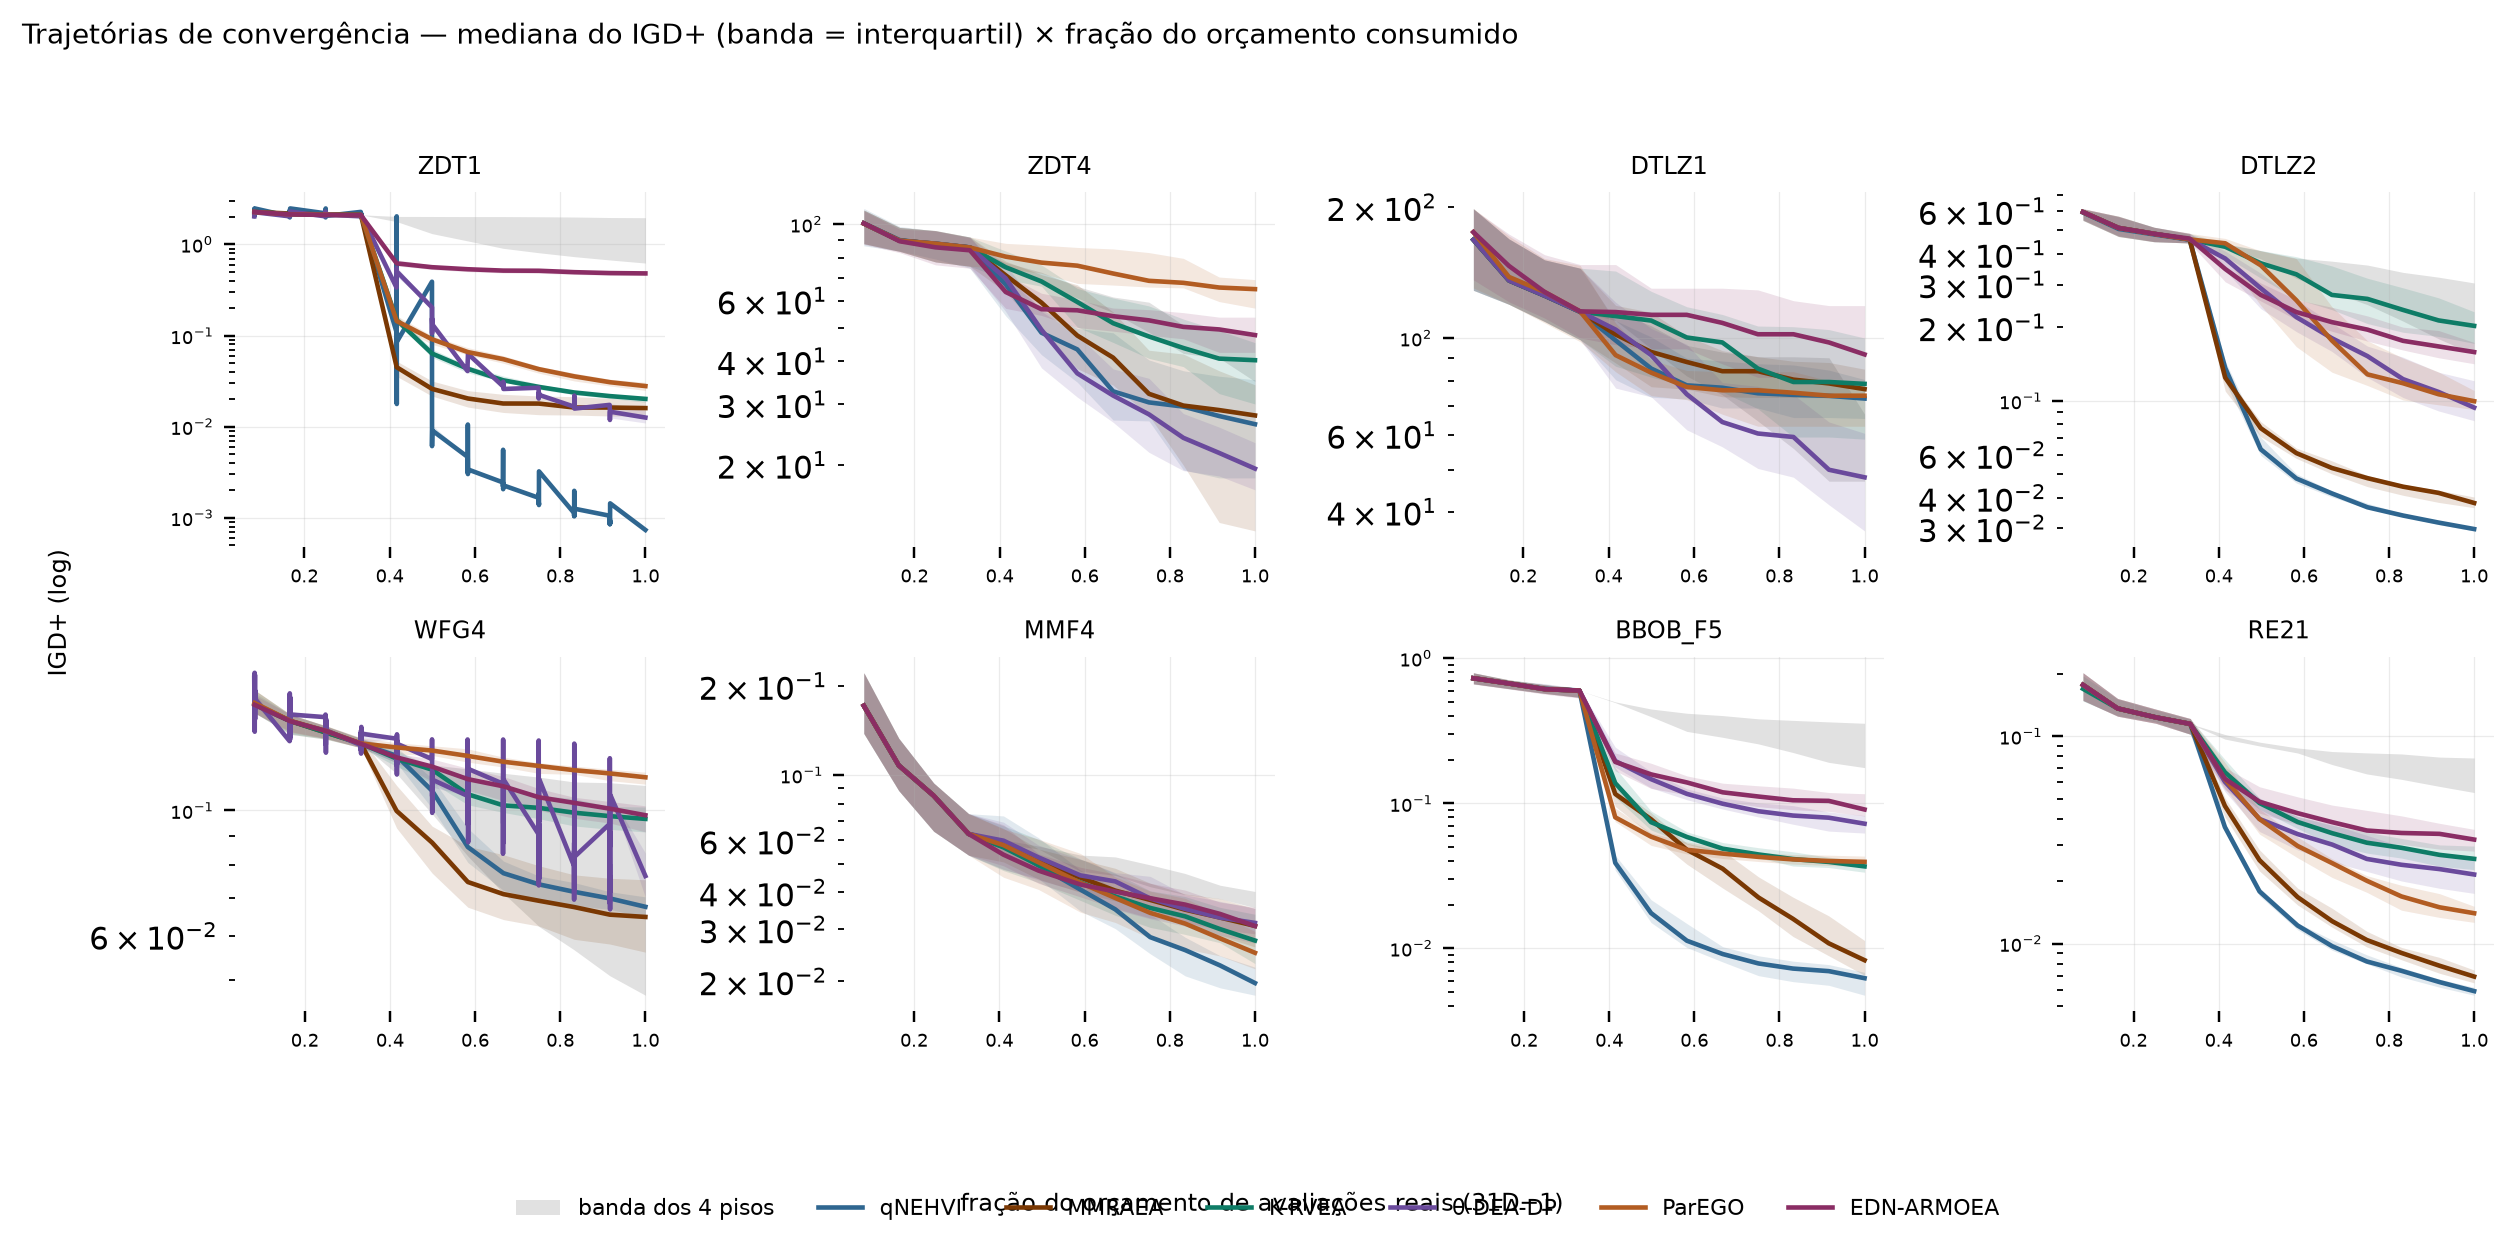

In [ ]:
TR = pd.read_parquet(os.path.join(CACHE, "trajetorias_2026-08-17.parquet"))
VIT = ["ZDT1", "ZDT4", "DTLZ1", "DTLZ2", "WFG4", "MMF4", "BBOB_F5", "RE21"]
DESTAQUE = ["c262", "c141", "b3", "c122", "b1", "e7"]
CORES = {"c262": "#2f6690", "c141": "#7a3803", "b3": "#0e7c66", "c122": "#6a4a9c",
         "b1": "#b25c22", "e7": "#8a2d64"}
fig, axs = plt.subplots(2, 4, figsize=(11.5, 5.6), sharex=False)
for ax, p in zip(axs.ravel(), VIT):
    sub = TR[TR.problema == p]
    # banda dos 4 pisos (cinza)
    pis = sub[sub.alg.isin(PISOS)]
    if len(pis):
        g = pis.groupby("frac_fe").igd_plus
        med_p = pis.groupby(["alg", "frac_fe"]).igd_plus.median().unstack(0)
        x = med_p.index.values
        ax.fill_between(x, med_p.min(axis=1), med_p.max(axis=1),
                        color="#bdbdbd", alpha=.45, lw=0, label="banda dos 4 pisos")
    for a in DESTAQUE:
        sa = sub[sub.alg == a]
        if not len(sa):
            continue
        g = sa.groupby("frac_fe").igd_plus
        x = np.array(sorted(sa.frac_fe.unique()))
        ax.plot(x, g.median().reindex(x), color=CORES[a], lw=1.5, label=NOME[a])
        ax.fill_between(x, g.quantile(.25).reindex(x), g.quantile(.75).reindex(x),
                        color=CORES[a], alpha=.14, lw=0)
    ax.set_title(p, fontsize=8)
    ax.set_yscale("log")
    ax.tick_params(labelsize=6)
    ax.grid(alpha=.25, lw=.4)
    [sp.set_visible(False) for sp in ax.spines.values()]
h, l = axs[0, 0].get_legend_handles_labels()
fig.legend(h, l, ncol=7, loc="lower center", fontsize=7.2, frameon=False)
fig.suptitle("Trajetórias de convergência — mediana do IGD+ (banda = interquartil) × fração do orçamento consumido",
             fontsize=9, x=0.01, ha="left")
fig.supxlabel("fração do orçamento de avaliações reais (31D−1)", fontsize=8)
fig.supylabel("IGD+ (log)", fontsize=8)
fig.tight_layout(rect=[0, .07, 1, .95])
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig57_trajetorias.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig57_trajetorias.png")]
fim = TR[TR.frac_fe > .99].groupby("alg").igd_plus.median()
meio = TR[(TR.frac_fe > .45) & (TR.frac_fe < .60)].groupby("alg").igd_plus.median()
print("A4 · quem mais melhora na 2ª metade (Δ mediano meio→fim, 8 problemas-vitrine):")
print(((meio - fim) / meio).dropna().sort_values(ascending=False).head(6).rename(index=NOME).round(3).to_string())


## A5+A6 · O modelo por dentro: a sonda (calibração) e o erro de fantasia

**Objetivo.** A LACUNA do corpus virando contribuição: nenhum exemplar valida σ×|erro| (e7 chega perto com MAE×STD). A sonda re-prediz os MESMOS 2.000 pontos a cada retreino → (a) o modelo melhora com as épocas? (b) o σ ordena o erro (ρ de Spearman)? (c) μ±2σ cobre o erro na taxa nominal? E a fantasia: o RMSE nos pontos que o algoritmo ESCOLHEU avaliar, por terço do orçamento — quem 'acredita demais' no próprio modelo.

A6 · calibração global (mediana de ρ(σ,|erro|) e cobertura 2σ por algoritmo):
            rho_sigma_erro  cobertura_2sigma
alg                                         
ParEGO               0.176             0.018
K-RVEA               0.550             0.918
EIM                  0.615             0.941
EDN-ARMOEA           0.395             0.529

A5 · fantasia (RMSE mediano nos pontos escolhidos, 3º terço):
alg
ParEGO         1.608
K-RVEA         0.333
CSEA             NaN
MMRAEA         2.044
PC-SAEA          NaN
EIM            5.042
EDN-ARMOEA     1.961
CLMEA         21.236


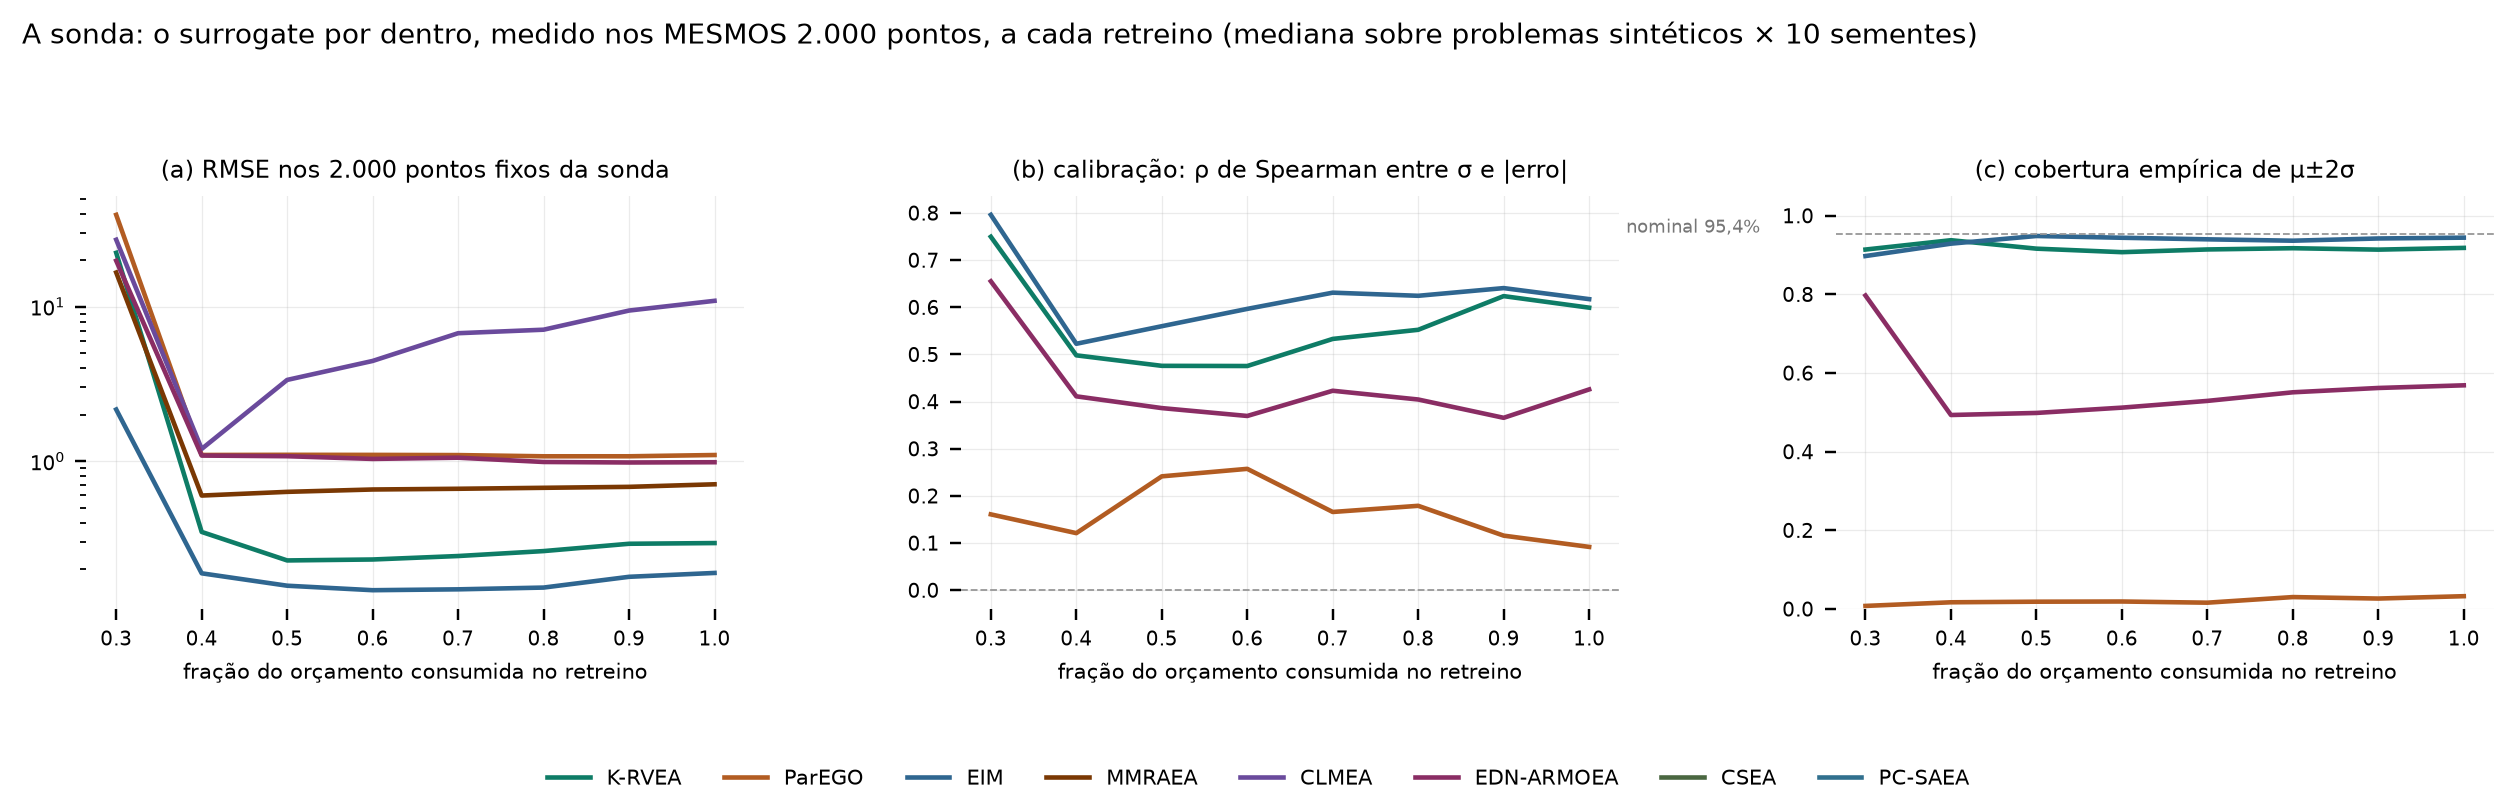

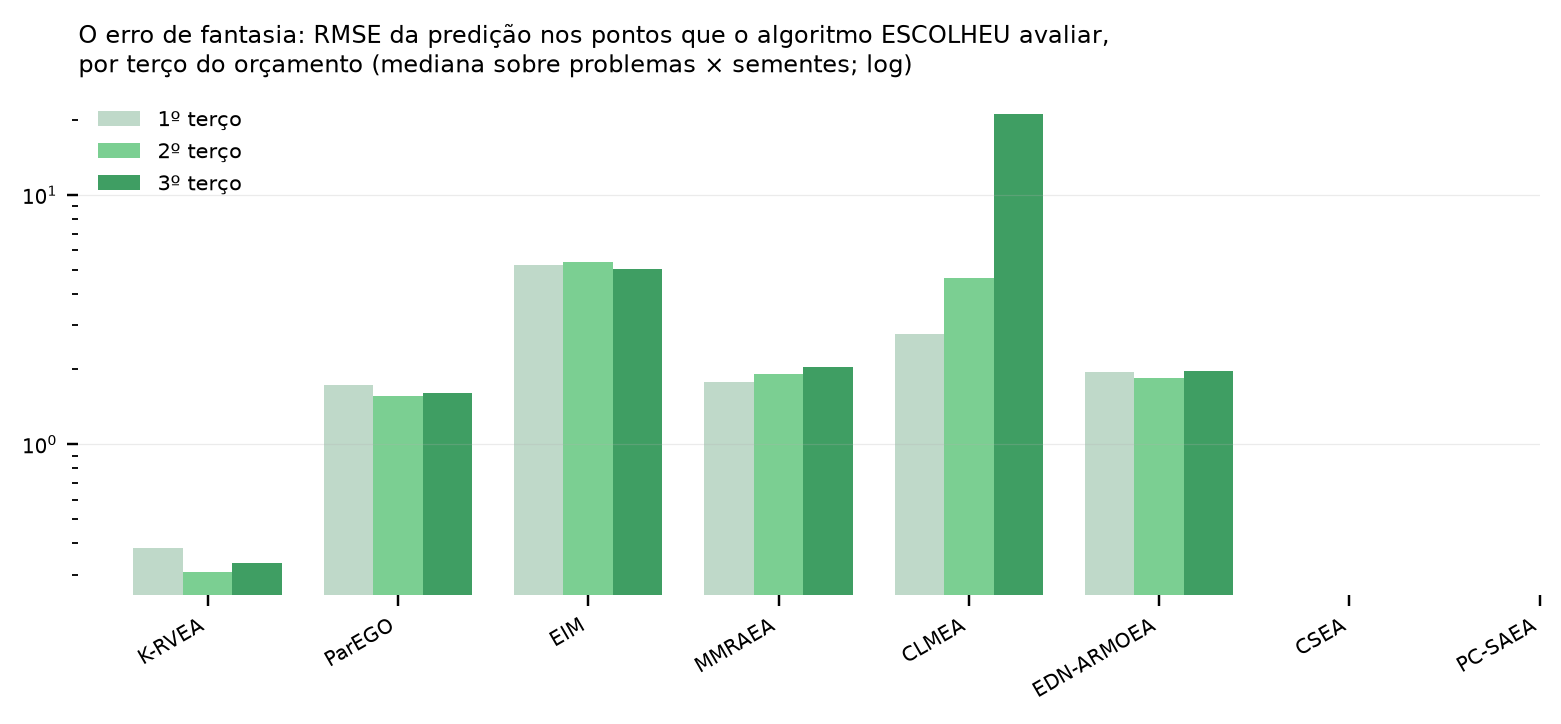

In [ ]:
SO = pd.read_parquet(os.path.join(CACHE, "sonda_2026-08-17.parquet"))
FA = pd.read_parquet(os.path.join(CACHE, "fantasia_2026-08-17.parquet"))
ALGS_S = [a for a in ["b3", "b1", "c238", "c141", "e74", "e7", "b4", "c217"] if a in SO.alg.unique()]
CORES_S = {"b3": "#0e7c66", "b1": "#b25c22", "c238": "#2f6690", "c141": "#7a3803",
           "e74": "#6a4a9c", "e7": "#8a2d64", "b4": "#4a6741", "c217": "#31708e"}
# fração do orçamento consumido no retreino (normaliza fe_treino_max por problema: maxfe=31D-1)
DD = {"ZDT1": 30, "ZDT3": 30, "ZDT4": 10, "ZDT6": 10, "DTLZ1": 7, "DTLZ2": 12,
      "DTLZ3": 12, "DTLZ4": 12, "DTLZ7": 22, "WFG1": 22, "WFG2": 22, "WFG4": 22,
      "WFG5": 22, "WFG9": 22, "MMF1": 2, "MMF4": 2, "MMF11_L": 2, "MMF16_20": 20,
      "BBOB_F1": 10, "BBOB_F5": 10, "BBOB_F17": 10, "BBOB_F22": 10, "BBOB_F37": 10,
      "BBOB_F49": 10, "BBOB_F55": 10}
SO["frac"] = SO.apply(lambda r: r.fe_treino_max / (31 * DD.get(r.problema, 10) - 1), axis=1)
SO["bucket"] = (SO.frac.clip(0, 1) * 10).round() / 10

fig, axs = plt.subplots(1, 3, figsize=(11.5, 3.6))
for a in ALGS_S:
    sa = SO[SO.alg == a]
    g = sa.groupby("bucket")
    x = sorted(sa.bucket.unique())
    axs[0].plot(x, g.rmse.median().reindex(x), color=CORES_S[a], lw=1.5, label=NOME[a])
    if sa.rho_sigma_erro.notna().any():
        axs[1].plot(x, g.rho_sigma_erro.median().reindex(x), color=CORES_S[a], lw=1.5)
        axs[2].plot(x, g.cobertura_2sigma.median().reindex(x), color=CORES_S[a], lw=1.5)
axs[0].set_yscale("log"); axs[0].set_title("(a) RMSE nos 2.000 pontos fixos da sonda", fontsize=8)
axs[1].axhline(0, color="#999999", lw=.6, ls="--")
axs[1].set_title("(b) calibração: ρ de Spearman entre σ e |erro|", fontsize=8)
axs[2].axhline(0.954, color="#999999", lw=.6, ls="--")
axs[2].text(.02, .957, "nominal 95,4%", fontsize=6, color="#777777")
axs[2].set_ylim(0, 1.05); axs[2].set_title("(c) cobertura empírica de μ±2σ", fontsize=8)
for ax in axs:
    ax.tick_params(labelsize=6.5); ax.grid(alpha=.25, lw=.4)
    ax.set_xlabel("fração do orçamento consumida no retreino", fontsize=7)
    [sp.set_visible(False) for sp in ax.spines.values()]
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, ncol=8, loc="lower center", fontsize=7, frameon=False)
fig.suptitle("A sonda: o surrogate por dentro, medido nos MESMOS 2.000 pontos, a cada retreino "
             "(mediana sobre problemas sintéticos × 10 sementes)", fontsize=9, x=.01, ha="left")
fig.tight_layout(rect=[0, .1, 1, .93])
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig58_sonda.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)

# fantasia: RMSE nos pontos ESCOLHIDOS, por terço do orçamento
fig, ax = plt.subplots(figsize=(7.2, 3.4))
w = 0.26
for t, cor, rot in [(1, "#bfd9c9", "1º terço"), (2, "#7bcf92", "2º terço"), (3, "#3f9e63", "3º terço")]:
    med = FA[FA.terco == t].groupby("alg").rmse.median().reindex(ALGS_S)
    ax.bar(np.arange(len(ALGS_S)) + (t - 2) * w, med.values, w, color=cor, label=rot)
ax.set_yscale("log")
ax.set_xticks(range(len(ALGS_S)))
ax.set_xticklabels([NOME[a] for a in ALGS_S], rotation=30, ha="right", fontsize=7)
ax.tick_params(labelsize=6.5); ax.grid(axis="y", alpha=.25, lw=.4)
[sp.set_visible(False) for sp in ax.spines.values()]
ax.legend(fontsize=7, frameon=False)
ax.set_title("O erro de fantasia: RMSE da predição nos pontos que o algoritmo ESCOLHEU avaliar,\n"
             "por terço do orçamento (mediana sobre problemas × sementes; log)", fontsize=8, loc="left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig59_fantasia.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig58_sonda.png"), os.path.join(FIGDIR, "fig59_fantasia.png")]
print("A6 · calibração global (mediana de ρ(σ,|erro|) e cobertura 2σ por algoritmo):")
print(SO.groupby("alg")[["rho_sigma_erro", "cobertura_2sigma"]].median().dropna().rename(index=NOME).round(3).to_string())
print("\nA5 · fantasia (RMSE mediano nos pontos escolhidos, 3º terço):")
print(FA[FA.terco == 3].groupby("alg").rmse.median().rename(index=NOME).round(3).to_string())


## A9 · Tempo × qualidade e a parede do retreino

**Objetivo.** O custo se paga? (a) tempo de parede mediano × rank de qualidade — quadrantes; (b) custo de retreino × dimensão (a parede O(n³) do GP vs alternativas). Ressalva da literatura (b3): tempos entre stacks são TENDÊNCIA, não número fino — aqui todos os sintéticos rodaram no mesmo parque (VMs Linux), com a heterogeneidade declarada na §4.9.

A9 · tempo mediano por execução (min) × rank médio IGD+:
              min   rank
alg                     
qNEHVI       35.9   3.83
MMRAEA        0.7   4.42
θ-DEA-DP     70.1   5.42
K-RVEA        1.7   6.00
CLMEA         4.9   7.04
EIM           7.5   7.38
ParEGO        7.6   7.75
SMS-EMOA      0.1   8.21
NSGA-II       0.1   9.17
NSGA-III      0.1   9.83
EDN-ARMOEA   27.2  10.38
JES         720.7  10.58
PC-SAEA       1.5  11.04
CSEA         11.0  11.04
qPOTS        14.6  12.38
MOEA/D        0.1  13.71
LBN-MOBO    105.0  14.83


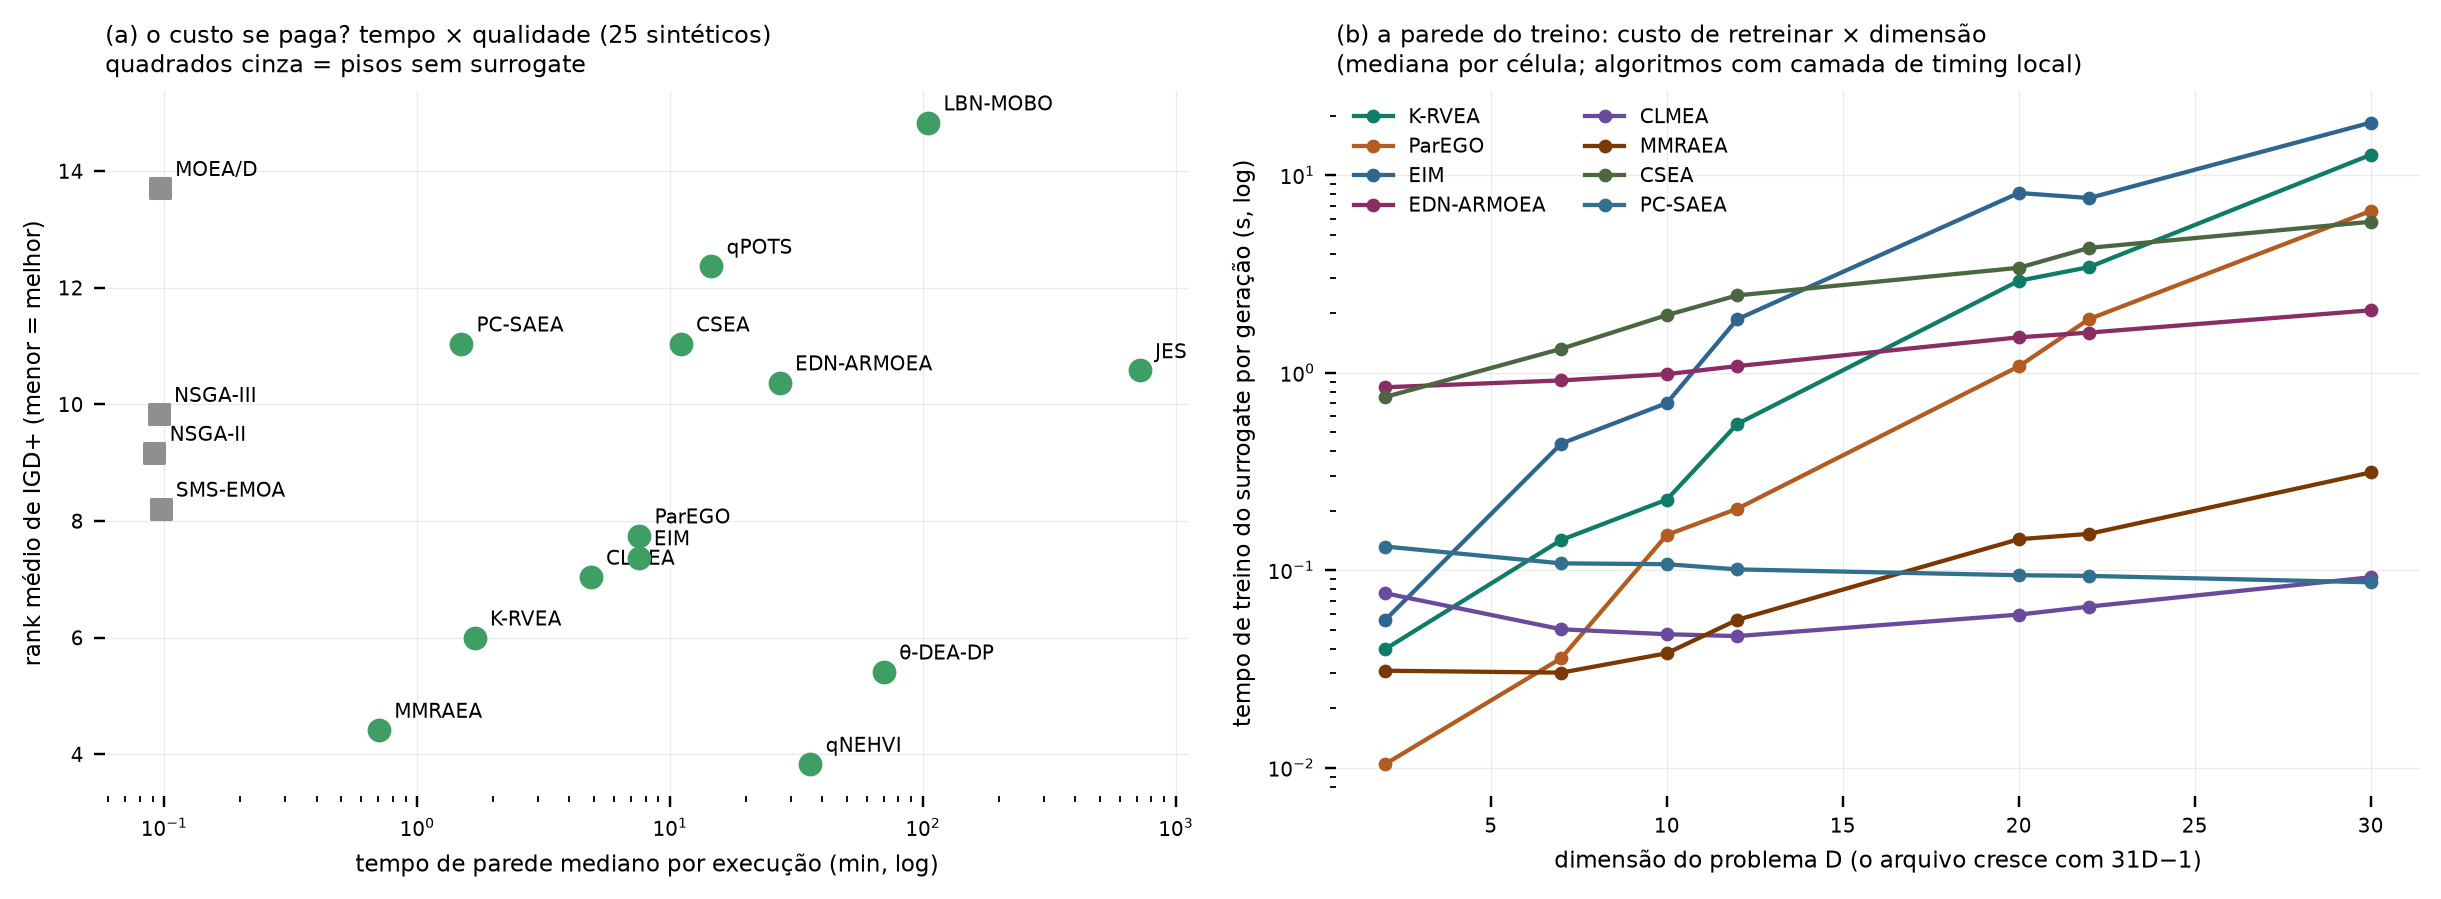

In [ ]:
TE = pd.read_parquet(os.path.join(CACHE, "tempo_2026-08-17.parquet"))
TE = TE[TE.problema.isin(PROBLEMAS[:25])]
# qualidade: rank médio IGD+ (online) já em MED_IGDP; offline por fora
med25 = on[on.problema.isin(PROBLEMAS[:25])].groupby(["problema", "alg"]).igd_plus.median().unstack()
rk = med25[[a for a in ONLINE if a in med25.columns]].dropna().rank(axis=1).mean()
twall = TE.groupby("alg").wall_total_s.median()

fig, axs = plt.subplots(1, 2, figsize=(11.2, 4.2))
ax = axs[0]
for a in [x for x in ONLINE if x in rk.index and x in twall.index]:
    piso = a in PISOS
    ax.scatter(twall[a] / 60, rk[a], s=46, c="#8f8f8f" if piso else "#3f9e63",
               marker="s" if piso else "o", zorder=3)
    ax.annotate(NOME[a], (twall[a] / 60, rk[a]), textcoords="offset points",
                xytext=(5, 4), fontsize=6.6)
ax.set_xscale("log")
ax.set_xlabel("tempo de parede mediano por execução (min, log)", fontsize=7.5)
ax.set_ylabel("rank médio de IGD+ (menor = melhor)", fontsize=7.5)
ax.set_title("(a) o custo se paga? tempo × qualidade (25 sintéticos)\n"
             "quadrados cinza = pisos sem surrogate", fontsize=8, loc="left")
ax.grid(alpha=.25, lw=.4); ax.tick_params(labelsize=6.5)
[sp.set_visible(False) for sp in ax.spines.values()]

ax = axs[1]
DD = {"ZDT1": 30, "ZDT3": 30, "ZDT4": 10, "ZDT6": 10, "DTLZ1": 7, "DTLZ2": 12,
      "DTLZ3": 12, "DTLZ4": 12, "DTLZ7": 22, "WFG1": 22, "WFG2": 22, "WFG4": 22,
      "WFG5": 22, "WFG9": 22, "MMF1": 2, "MMF4": 2, "MMF11_L": 2, "MMF16_20": 20,
      "BBOB_F1": 10, "BBOB_F5": 10, "BBOB_F17": 10, "BBOB_F22": 10, "BBOB_F37": 10,
      "BBOB_F49": 10, "BBOB_F55": 10}
TE["D"] = TE.problema.map(DD)
TE["fit_por_ger"] = TE.fit_total_s / TE.n_ger.clip(lower=1)
ALGF = [a for a in ["b3", "b1", "c238", "e7", "e74", "c141", "b4", "c217"] if a in TE.alg.unique()]
CORES_S = {"b3": "#0e7c66", "b1": "#b25c22", "c238": "#2f6690", "c141": "#7a3803",
           "e74": "#6a4a9c", "e7": "#8a2d64", "b4": "#4a6741", "c217": "#31708e"}
for a in ALGF:
    g = TE[TE.alg == a].groupby("D").fit_por_ger.median()
    ax.plot(g.index, g.values, "o-", lw=1.4, ms=3.5, color=CORES_S[a], label=NOME[a])
ax.set_yscale("log")
ax.set_xlabel("dimensão do problema D (o arquivo cresce com 31D−1)", fontsize=7.5)
ax.set_ylabel("tempo de treino do surrogate por geração (s, log)", fontsize=7.5)
ax.set_title("(b) a parede do treino: custo de retreinar × dimensão\n"
             "(mediana por célula; algoritmos com camada de timing local)", fontsize=8, loc="left")
ax.grid(alpha=.25, lw=.4); ax.tick_params(labelsize=6.5); ax.legend(fontsize=6.4, frameon=False, ncol=2)
[sp.set_visible(False) for sp in ax.spines.values()]
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig5A_tempo_qualidade.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig5A_tempo_qualidade.png")]
print("A9 · tempo mediano por execução (min) × rank médio IGD+:")
tq = pd.DataFrame({"min": (twall / 60).round(1), "rank": rk.round(2)}).dropna()
print(tq.sort_values("rank").rename(index=NOME).to_string())


## A7+A10 · O que a evolução comprou + utilidade do infill

**Objetivo.** A7: os 3 pares seminal→SOTA rodando sob o MESMO DoE (b4→c217, b1→c262, b3→e7) — quanto do progresso publicado sobrevive ao confronto pareado. A10: a métrica do EDN-ARMOEA — fração das avaliações da busca que entram na fronteira corrente (aproveitamento do orçamento).

A7 · placar dos pares (nº de problemas em que o SOTA vence o seminal):
  CSEA → PC-SAEA           12 × 13
  ParEGO → qNEHVI          18 ×  5
  K-RVEA → EDN-ARMOEA       3 × 22

A10 · utilidade do infill (mediana):
alg
θ-DEA-DP      0.458
MMRAEA        0.412
SMS-EMOA      0.393
NSGA-II       0.385
K-RVEA        0.375
NSGA-III      0.362
qNEHVI        0.317
CSEA          0.276
PC-SAEA       0.275
ParEGO        0.275
MOEA/D        0.218
JES           0.213
EDN-ARMOEA    0.213
CLMEA         0.200
qPOTS         0.160
EIM           0.154
LBN-MOBO      0.075


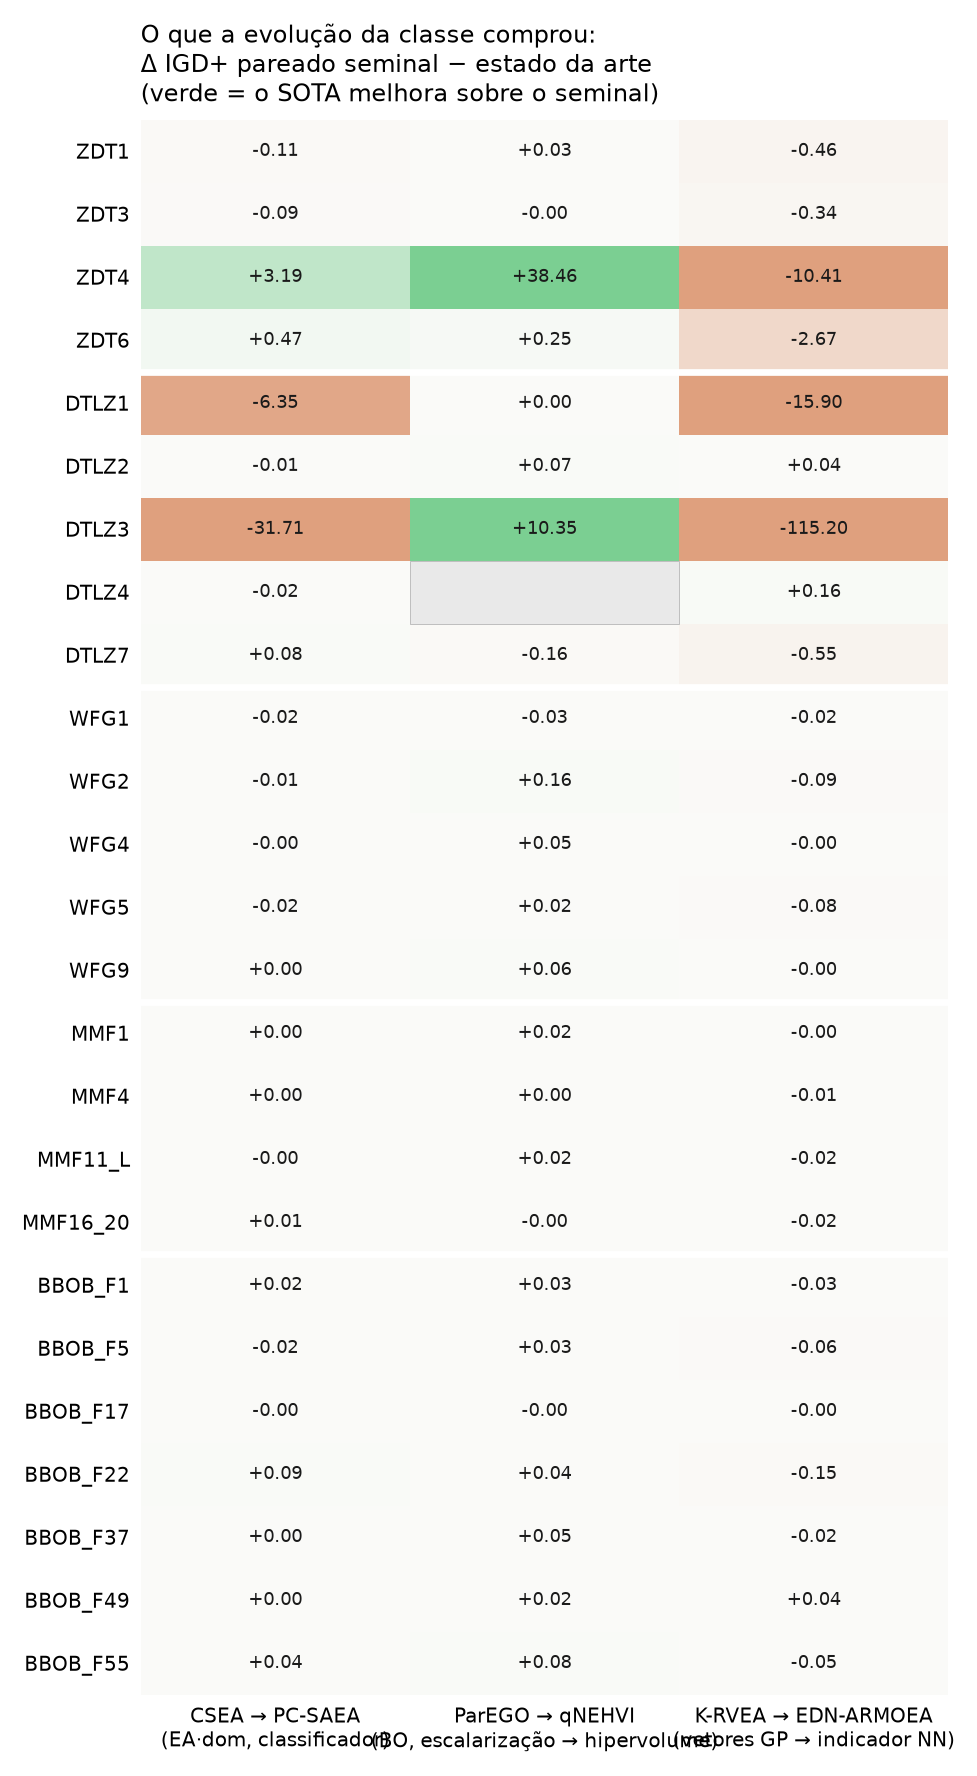

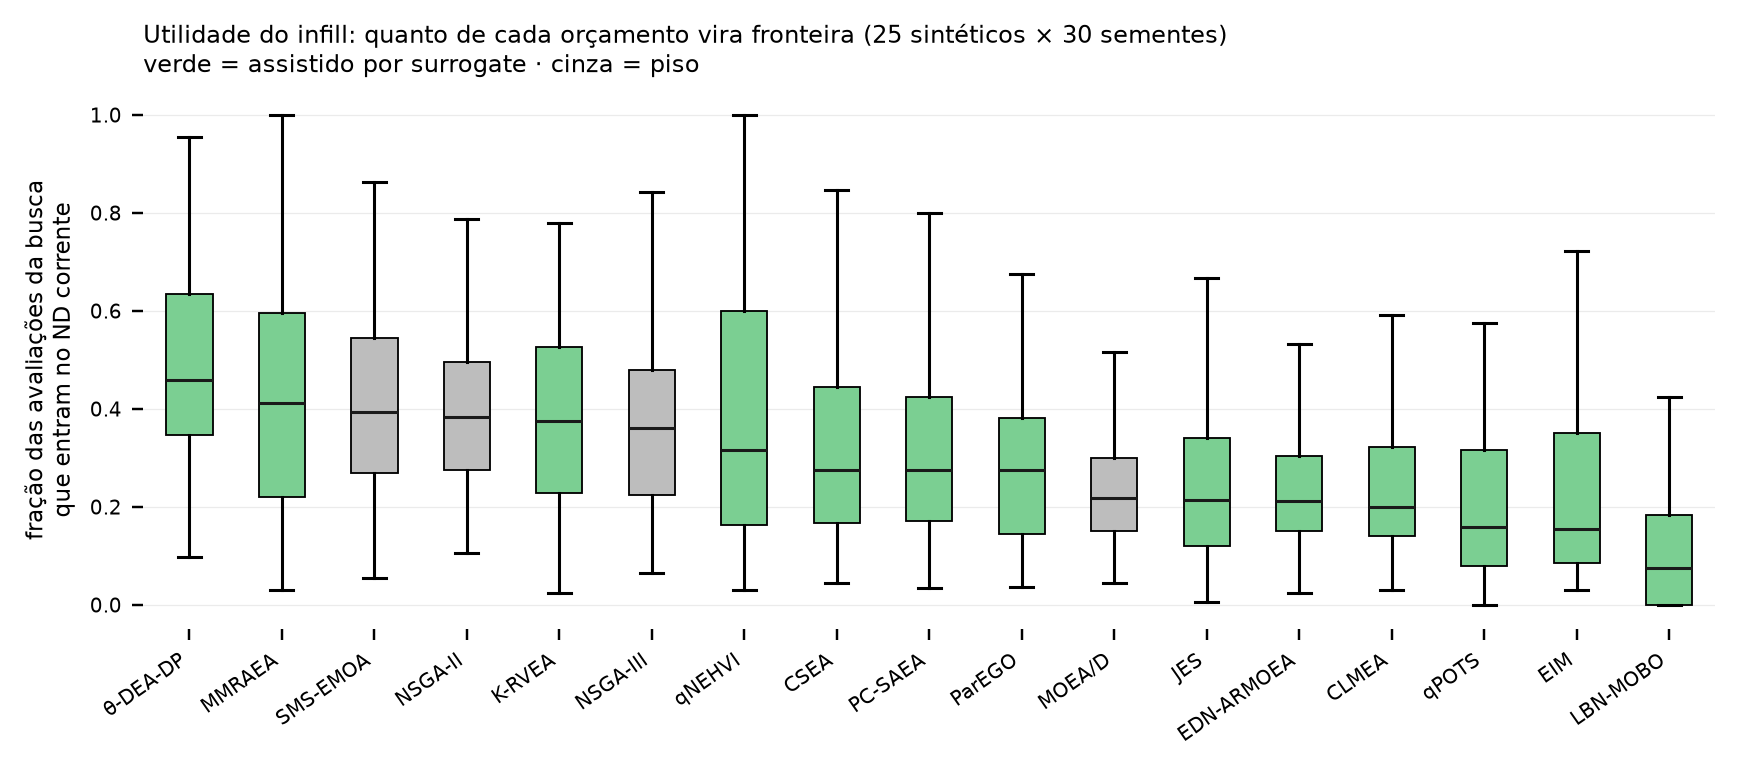

In [ ]:
SINTS = PROBLEMAS[:25]
# ---- A7 · pares seminal → SOTA (DoE compartilhado ⇒ pareado por semente)
PARES = [("b4", "c217", "CSEA → PC-SAEA\n(EA·dom, classificador)"),
         ("b1", "c262", "ParEGO → qNEHVI\n(BO, escalarização → hipervolume)"),
         ("b3", "e7", "K-RVEA → EDN-ARMOEA\n(vetores GP → indicador NN)")]
DP = pd.DataFrame(index=SINTS, columns=[t for _, _, t in PARES], dtype=float)
for sem, sota, t in PARES:
    for p in SINTS:
        a = on[(on.alg == sem) & (on.problema == p)][["semente", "igd_plus"]].dropna()
        b = on[(on.alg == sota) & (on.problema == p)][["semente", "igd_plus"]].dropna()
        j = a.merge(b, on="semente", suffixes=("_sem", "_sota"))
        if len(j) >= 5:
            DP.loc[p, t] = float((j.igd_plus_sem - j.igd_plus_sota).median())  # >0 = SOTA melhor
fig, ax = plt.subplots(figsize=(4.6, 8.2))
V = DP.values.astype(float)
lim = float(np.nanpercentile(np.abs(V), 92))
ax.imshow(np.ma.masked_invalid(np.clip(V, -lim, lim)), cmap=DIVERG, vmin=-lim, vmax=lim, aspect="auto")
for i in range(V.shape[0]):
    for j in range(V.shape[1]):
        if np.isnan(V[i, j]):
            ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, color="#e9e9e9", hatch="///", ec="#bbbbbb", lw=.3))
        else:
            ax.text(j, i, f"{V[i, j]:+.2f}", ha="center", va="center", fontsize=6, color="#1a1a1a")
ax.set_xticks(range(len(PARES)))
ax.set_xticklabels([t for _, _, t in PARES], fontsize=6.5)
ax.set_yticks(range(len(SINTS))); ax.set_yticklabels(SINTS, fontsize=6.5)
for s in sorted(SEPARA_APOS - {24}):
    ax.axhline(s + .5, color="white", lw=2.2)
ax.tick_params(length=0); [sp.set_visible(False) for sp in ax.spines.values()]
ax.set_title("O que a evolução da classe comprou:\nΔ IGD+ pareado seminal − estado da arte\n(verde = o SOTA melhora sobre o seminal)", fontsize=8, loc="left")
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig5B_pares.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)

# ---- A10 · utilidade do infill (métrica do EDN-ARMOEA)
IN = pd.read_parquet(os.path.join(CACHE, "infill_2026-08-17.parquet"))
IN = IN[IN.problema.isin(SINTS)]
ordem = IN.groupby("alg").frac_util.median().reindex(ONLINE).dropna().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8.0, 3.6))
dados = [IN[IN.alg == a].frac_util.dropna().values for a in ordem.index]
bp = ax.boxplot(dados, showfliers=False, patch_artist=True, medianprops=dict(color="#1a1a1a"))
for i, (patch, a) in enumerate(zip(bp["boxes"], ordem.index)):
    patch.set_facecolor("#bdbdbd" if a in PISOS else "#7bcf92")
    patch.set_linewidth(.6)
ax.set_xticklabels([NOME[a] for a in ordem.index], rotation=35, ha="right", fontsize=7)
ax.set_ylabel("fração das avaliações da busca\nque entram no ND corrente", fontsize=7.5)
ax.set_title("Utilidade do infill: quanto de cada orçamento vira fronteira (25 sintéticos × 30 sementes)\n"
             "verde = assistido por surrogate · cinza = piso", fontsize=8, loc="left")
ax.grid(axis="y", alpha=.25, lw=.4); ax.tick_params(labelsize=6.5)
[sp.set_visible(False) for sp in ax.spines.values()]
fig.tight_layout()
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig5C_infill.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig5B_pares.png"), os.path.join(FIGDIR, "fig5C_infill.png")]
print("A7 · placar dos pares (nº de problemas em que o SOTA vence o seminal):")
for _, _, t in PARES:
    col = DP[t].dropna()
    print(f"  {t.splitlines()[0]:24s} {int((col > 0).sum()):2d} × {int((col < 0).sum()):2d}")
print("\nA10 · utilidade do infill (mediana):")
print(ordem.rename(index=NOME).round(3).to_string())


## A8 · Fronteiras representativas (execução mediana)

**Objetivo.** A intuição visual (convenção do corpus: plotar a run do IGD+ MEDIANO, nunca a melhor): frente desconexa 2D e 3D + multimodal. Poucas figuras, escolhidas por característica.

A8 · fronteiras da execução mediana exportadas (ZDT3, DTLZ7, MMF4 × qNEHVI/K-RVEA/NSGA-II)


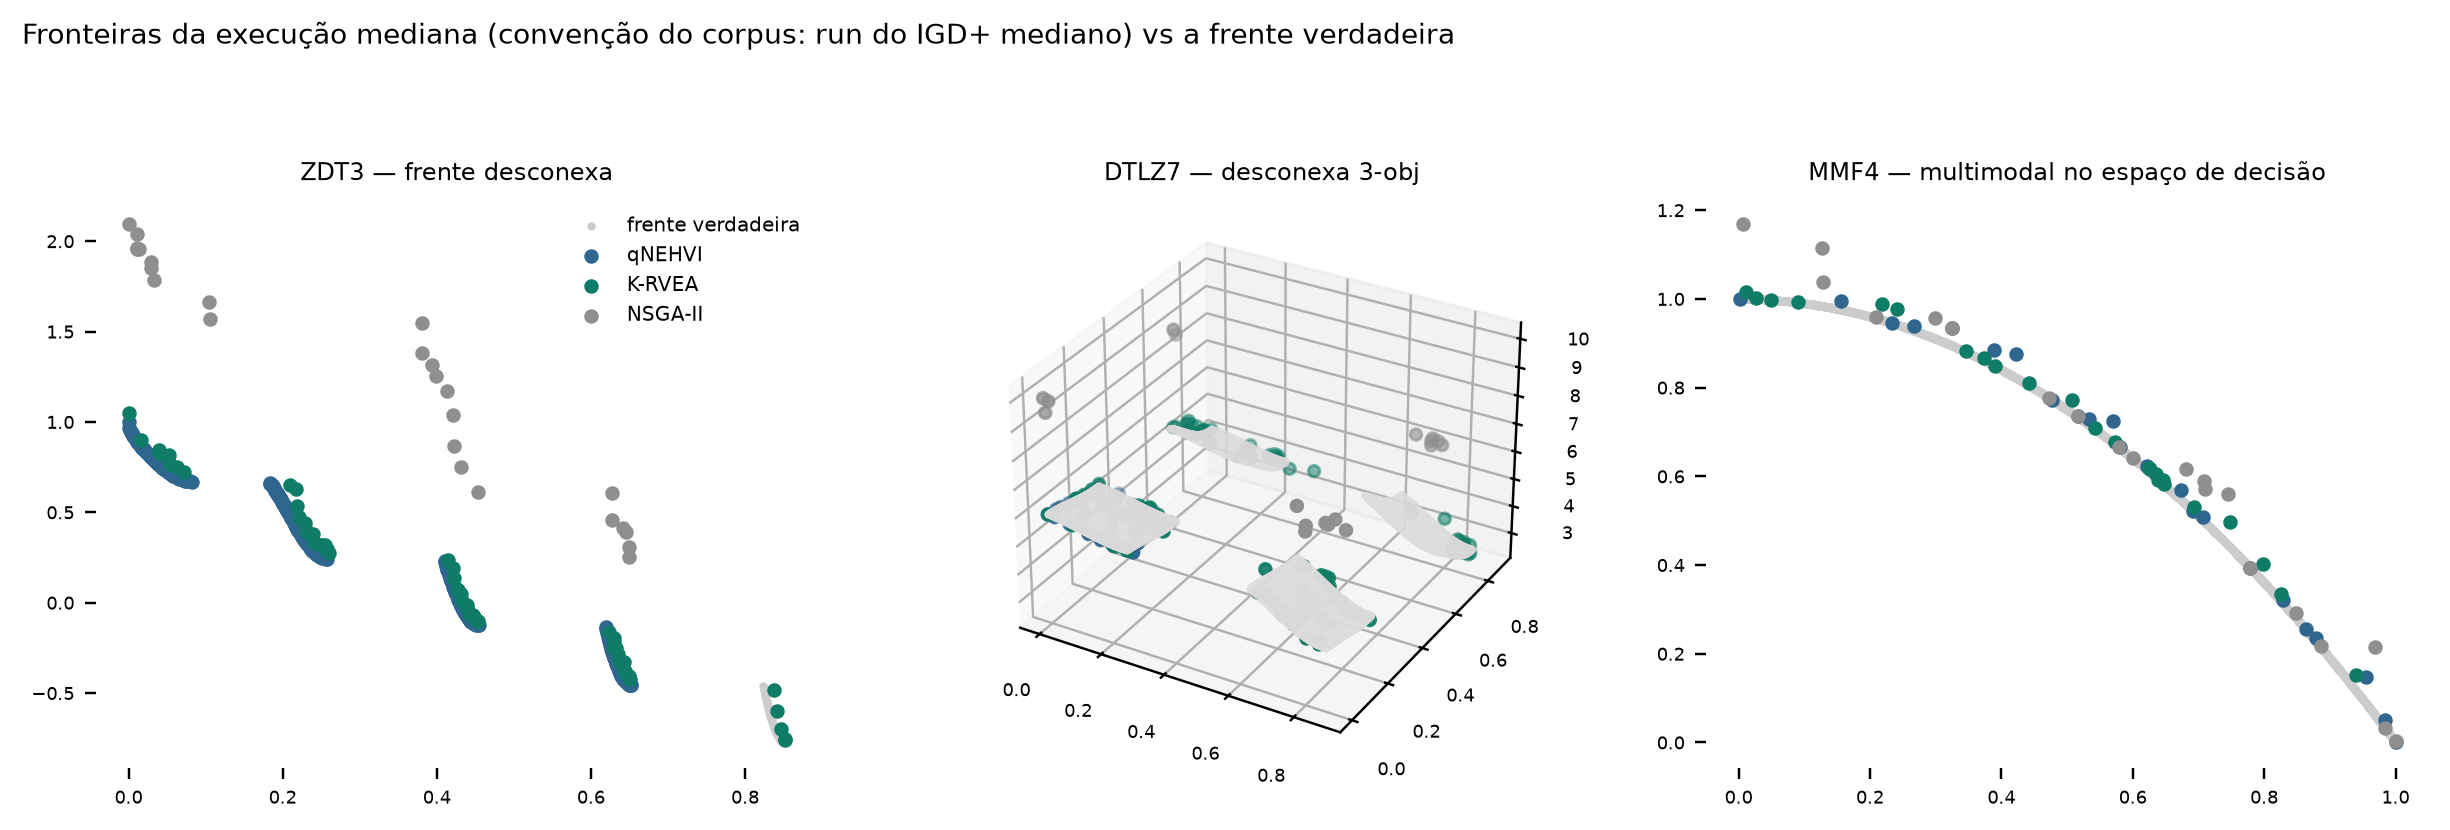

In [ ]:
# A8 · fronteiras representativas — convenção do corpus: a execução da MEDIANA do IGD+
CASOS = [("ZDT3", "frente desconexa"), ("DTLZ7", "desconexa 3-obj"), ("MMF4", "multimodal no espaço de decisão")]
MOSTRAR = ["c262", "b3", "nsga2"]
CORES_F = {"c262": "#2f6690", "b3": "#0e7c66", "nsga2": "#8f8f8f"}
fig = plt.figure(figsize=(11.2, 3.8))
for ci, (p, rot) in enumerate(CASOS):
    tresd = p == "DTLZ7"
    ax = fig.add_subplot(1, 3, ci + 1, projection="3d" if tresd else None)
    Ftrue = metrics.true_front_raw(p, 2000)
    if tresd:
        ax.scatter(Ftrue[:, 0], Ftrue[:, 1], Ftrue[:, 2], s=2, c="#dddddd", alpha=.5, label="frente verdadeira")
    else:
        o = np.argsort(Ftrue[:, 0])
        ax.scatter(Ftrue[o, 0], Ftrue[o, 1], s=3, c="#cccccc", label="frente verdadeira")
    for a in MOSTRAR:
        sub = on[(on.alg == a) & (on.problema == p)].dropna(subset=["igd_plus"])
        if not len(sub):
            continue
        smed = sub.iloc[(sub.igd_plus - sub.igd_plus.median()).abs().argsort()].iloc[0].semente
        fs = glob.glob(os.path.join(CORPUS, a, p, str(int(smed)), "*__real.parquet"))
        if not fs:
            continue
        t = pq.read_table(fs[0])
        fc = sorted([c for c in t.column_names if re.fullmatch(r"f\d+", c)], key=lambda c: int(c[1:]))
        F = np.column_stack([np.asarray(t.column(c), float) for c in fc])
        nd = metrics.nondominated_front(F)
        if tresd:
            ax.scatter(nd[:, 0], nd[:, 1], nd[:, 2], s=14, color=CORES_F[a], label=NOME[a])
        else:
            ax.scatter(nd[:, 0], nd[:, 1], s=14, color=CORES_F[a], label=NOME[a])
    ax.set_title(f"{p} — {rot}", fontsize=8)
    ax.tick_params(labelsize=6)
    if not tresd:
        [sp.set_visible(False) for sp in ax.spines.values()]
    if ci == 0:
        ax.legend(fontsize=6.5, frameon=False)
fig.suptitle("Fronteiras da execução mediana (convenção do corpus: run do IGD+ mediano) vs a frente verdadeira",
             fontsize=9, x=.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, .93])
for ext in ("pdf", "png"):
    fig.savefig(os.path.join(FIGDIR, f"fig5D_fronteiras.{ext}"), dpi=220, bbox_inches="tight")
plt.close(fig)
EMBED_PNG = [os.path.join(FIGDIR, "fig5D_fronteiras.png")]
print("A8 · fronteiras da execução mediana exportadas (ZDT3, DTLZ7, MMF4 × qNEHVI/K-RVEA/NSGA-II)")


## §8 · O que este notebook ainda NÃO faz (fila declarada)

1. **Escadinhas por característica (§5.3 da dissertação)** — exige o
   congelamento do corpus + a matriz `characteristics.csv` re-derivada (D98).
2. **Análise da sonda (σ reportado × erro real)** — camada ③ dos volumosos
   mora no bucket; baixar antes (censo 403 pendente, escalação F30).
3. **Testes estatísticos (§14: Friedman/Nemenyi, signed-rank pareado,
   bayesiano)** — decisão de família/multiplicidade é do AUTOR (D100).
4. **DDMOP7 fase 2** — régua pooled pós-hoc (D102.3) e re-execução da §12.
5. **Attainment worst-case (D52)** e coordenadas paralelas many-objective — próxima leva.
6. **Fantasia GERACIONAL completa** (fronteira acreditada por geração, via ② + ③ do bucket).